In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('datasets/watchbase_data_preprocessed_scrapy.csv')
df.head()

,Url,Brand,Model,Movement,Limited,Case Material,Glass,Case Back,Case Shape,Case Diameter,Water Resistance,Dial Color,Dial Indexes,Dial Hands,Price
0,https://watchbase.com/panerai/pocket-watches/p...,Panerai,Pocket Watches,Panerai caliber P.3000/10,Yes,White Gold,Sapphire,Hunter,Cushion,50.0,50.0,Black,Mixed,Stick,63500.0
1,https://watchbase.com/patek-philippe/cubitus/5...,Patek Philippe,Cubitus,Patek Philippe caliber 26‑330 S C,No,Stainless Steel,Sapphire,Open,Square,45.0,30.0,Blue,Stick / Dot,Stick,62280.0
2,https://watchbase.com/patek-philippe/cubitus/5...,Patek Philippe,Cubitus,Patek Philippe caliber 240 PS CI J LU,No,Platinum,Sapphire,Open,Square,45.0,30.0,Blue,Stick / Dot,Stick,89830.0
3,https://watchbase.com/patek-philippe/cubitus/5...,Patek Philippe,Cubitus,Patek Philippe caliber 26‑330 S C,No,Stainless Steel,Sapphire,Open,Square,45.0,30.0,Green,Stick / Dot,Stick,41920.0
4,https://watchbase.com/patek-philippe/cubitus/7...,Patek Philippe,Cubitus,Patek Philippe caliber 26‑330 S C/434,No,Rose Gold,Sapphire,Open,Square,40.0,30.0,Brown,Stick / Dot,Stick,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6298 entries, 0 to 6297
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Url               6298 non-null   object 
 1   Brand             6298 non-null   object 
 2   Model             6298 non-null   object 
 3   Movement          6281 non-null   object 
 4   Limited           6298 non-null   object 
 5   Case Material     6298 non-null   object 
 6   Glass             6298 non-null   object 
 7   Case Back         6298 non-null   object 
 8   Case Shape        6298 non-null   object 
 9   Case Diameter     6298 non-null   float64
 10  Water Resistance  6298 non-null   float64
 11  Dial Color        6298 non-null   object 
 12  Dial Indexes      6298 non-null   object 
 13  Dial Hands        6298 non-null   object 
 14  Price             5135 non-null   float64
dtypes: float64(3), object(12)
memory usage: 738.2+ KB


In [4]:
cat_cols = ['Brand', 'Model', 'Limited', 'Case Material', 'Glass', 'Case Back', 'Case Shape', 'Dial Color', 'Dial Indexes', 'Dial Hands']
num_cols = ['Case Diameter', 'Water Resistance', 'Price']

### Numeric Data Analysis

##### EDA

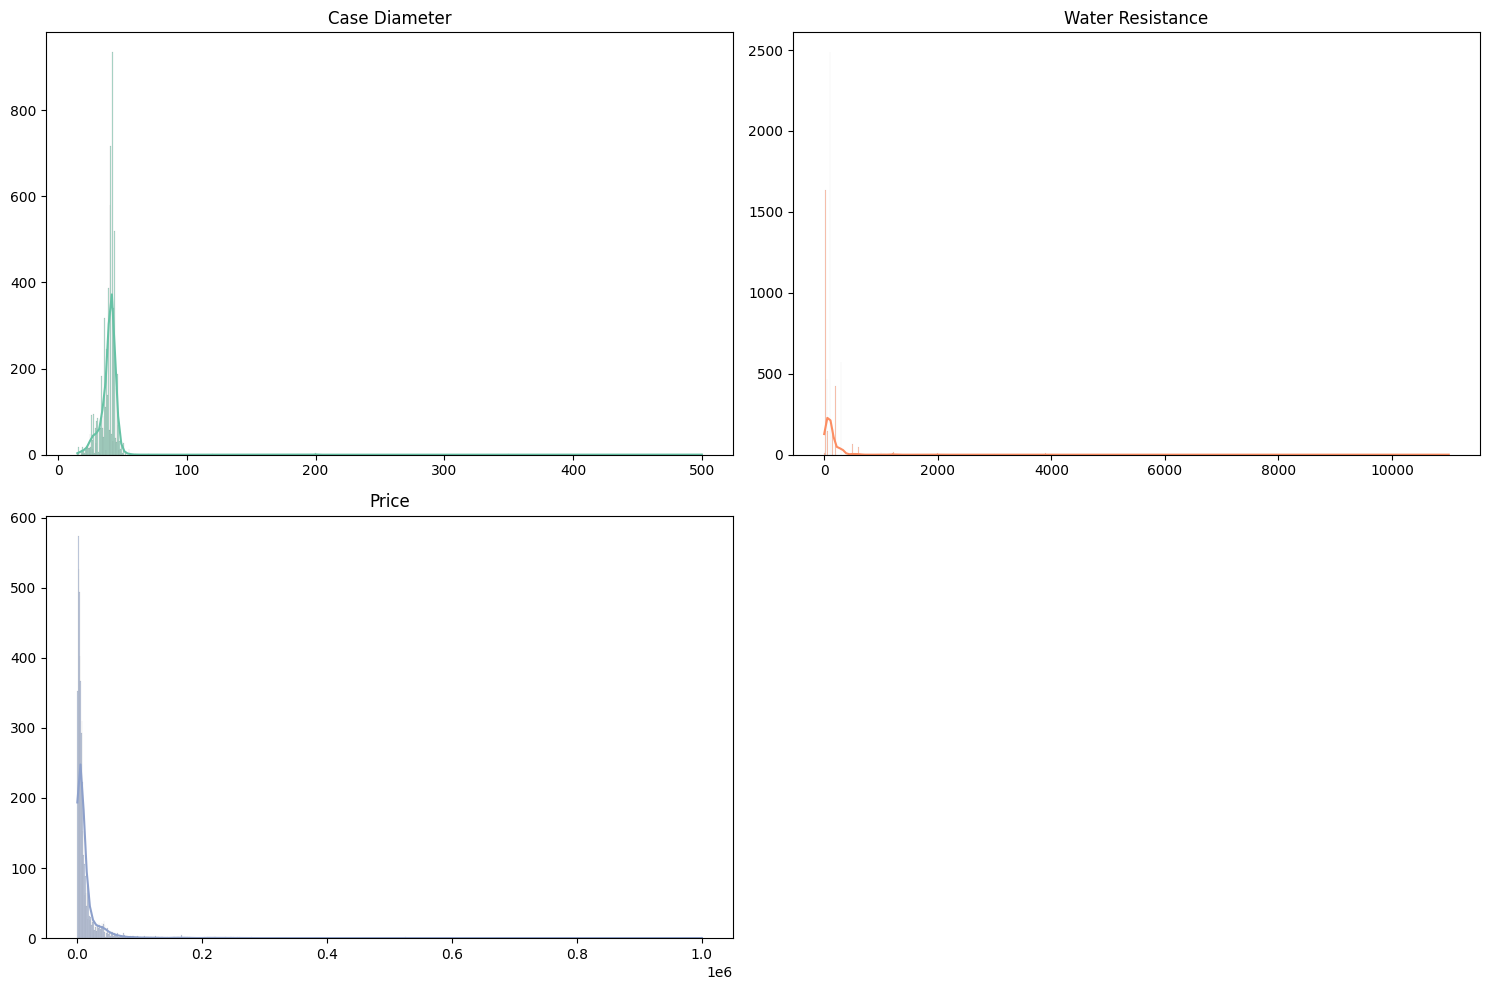

In [5]:
palette = sns.color_palette("Set2", n_colors=len(num_cols))

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True, color=palette[i])
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

**1. Biểu đồ "Case Diameter" (Đường kính vỏ)**

**- Nhận xét:**
  - Phân bố lệch phải (right-skewed): Hầu hết các giá trị đường kính vỏ tập trung ở phía bên trái, với một đỉnh rõ rệt quanh giá trị nhỏ (có thể là dưới 100). Sau đó, tần suất giảm dần khi đường kính vỏ tăng lên.
  - Giá trị ngoại lệ (outliers): Có vẻ có một số giá trị đường kính vỏ rất lớn (gần 500), với tần suất thấp, cho thấy khả năng có các giá trị ngoại lệ.
  - Phạm vi phổ biến: Phần lớn dữ liệu nằm trong khoảng từ 0 đến khoảng 100-150.

**- Hướng khai phá dữ liệu:**
  - Xử lý giá trị ngoại lệ: Cần kiểm tra các giá trị đường kính vỏ rất lớn. Có thể do lỗi nhập liệu, hoặc thực sự có những sản phẩm có kích thước đặc biệt. Tùy thuộc vào mục đích phân tích, có thể cần loại bỏ, biến đổi, hoặc tìm hiểu nguyên nhân của những giá trị này.
  - Phân nhóm (binning): Có thể phân nhóm "Case Diameter" thành các khoảng để dễ dàng phân tích hơn, ví dụ: nhỏ, trung bình, lớn.
  - Mối quan hệ với các biến khác: Khám phá mối quan hệ giữa "Case Diameter" với "Price" và "Water Resistance". Ví dụ: liệu đồng hồ có đường kính lớn hơn có xu hướng đắt hơn hoặc có khả năng chống nước tốt hơn không?
  - Ý nghĩa kinh doanh: Đường kính vỏ là một yếu tố quan trọng trong thiết kế đồng hồ. Phân tích này có thể giúp hiểu rõ hơn về sở thích của khách hàng đối với kích thước đồng hồ. 
  
**2. Biểu đồ "Water Resistance" (Khả năng chống nước)**

**- Nhận xét:**
  - Phân bố cực kỳ lệch phải: Đa số các sản phẩm có khả năng chống nước rất thấp (tập trung gần 0), với một đỉnh rất cao. Điều này cho thấy phần lớn sản phẩm không có khả năng chống nước cao hoặc chỉ có khả năng chống nước cơ bản.
  - Giá trị ngoại lệ đáng kể: Có một số giá trị chống nước cực kỳ cao (lên đến 10000), với tần suất rất thấp. Đây chắc chắn là các giá trị ngoại lệ hoặc đại diện cho các sản phẩm chuyên biệt (ví dụ: đồng hồ lặn chuyên nghiệp).
  - Sự phân tán: Dữ liệu rất rời rạc ở các mức chống nước cao.

**- Hướng khai phá dữ liệu:**
  - Xử lý giá trị ngoại lệ: Các giá trị chống nước cực lớn cần được xem xét kỹ lưỡng. Chúng có thể đại diện cho một phân khúc sản phẩm khác biệt.
  - Phân loại khả năng chống nước: Thay vì sử dụng giá trị số, có thể phân loại "Water Resistance" thành các nhóm (ví dụ: "Không chống nước", "Chống nước cơ bản (30m)", "Chống nước đi mưa/rửa tay (50m)", "Chống nước đi bơi (100m)", "Chống nước lặn (200m+)"...). Điều này sẽ giúp phân tích dễ dàng và có ý nghĩa hơn.
  - Mối quan hệ với các biến khác: Xem xét mối quan hệ giữa "Water Resistance" với "Price" và "Case Diameter". Ví dụ: liệu đồng hồ chống nước tốt hơn có đắt hơn không? Có mối liên hệ nào giữa kích thước và khả năng chống nước không?
  - Ý nghĩa kinh doanh: Khả năng chống nước là một tính năng quan trọng đối với nhiều người dùng. Phân tích này có thể giúp xác định phân khúc thị trường và chiến lược sản phẩm. 
  
**3. Biểu đồ "Price" (Giá)**

**- Nhận xét:**
  - Phân bố cực kỳ lệch phải: Tương tự như "Water Resistance", đa số các sản phẩm có giá thấp, với một đỉnh rất cao gần 0. Điều này cho thấy thị trường có nhiều sản phẩm giá cả phải chăng.
  - Giá trị ngoại lệ rõ rệt: Có một "đuôi" dài các sản phẩm có giá rất cao (lên đến 250000), với tần suất giảm dần. Đây là các sản phẩm cao cấp hoặc xa xỉ.
  - Khoảng giá phổ biến: Phần lớn các sản phẩm có giá dưới 50000.

**- Hướng khai phá dữ liệu:**
  - Xử lý giá trị ngoại lệ/biến đổi: Các giá trị giá rất cao có thể được xem xét là ngoại lệ hoặc là một phân khúc thị trường riêng biệt. Để làm việc với phân bố lệch, có thể cân nhắc biến đổi logarit (log transformation) cho biến "Price" để làm cho phân bố gần với phân bố chuẩn hơn, điều này hữu ích cho một số mô hình thống kê.
  - Phân khúc thị trường: Phân loại "Price" thành các phân khúc giá (ví dụ: "Phổ thông", "Tầm trung", "Cao cấp", "Xa xỉ") để phân tích sâu hơn về đặc điểm của từng phân khúc.
  - Mối quan hệ với các biến khác: Đây là biến mục tiêu quan trọng. Khám phá mối quan hệ giữa "Price" với "Case Diameter", "Water Resistance" và các thuộc tính khác (nếu có) để hiểu yếu tố nào ảnh hưởng đến giá. Ví dụ: những yếu tố nào đóng góp vào việc tạo nên một sản phẩm đắt tiền?
  - Phân tích nhân tố ảnh hưởng đến giá: Sử dụng hồi quy hoặc các mô hình khác để xác định các yếu tố dự đoán giá.

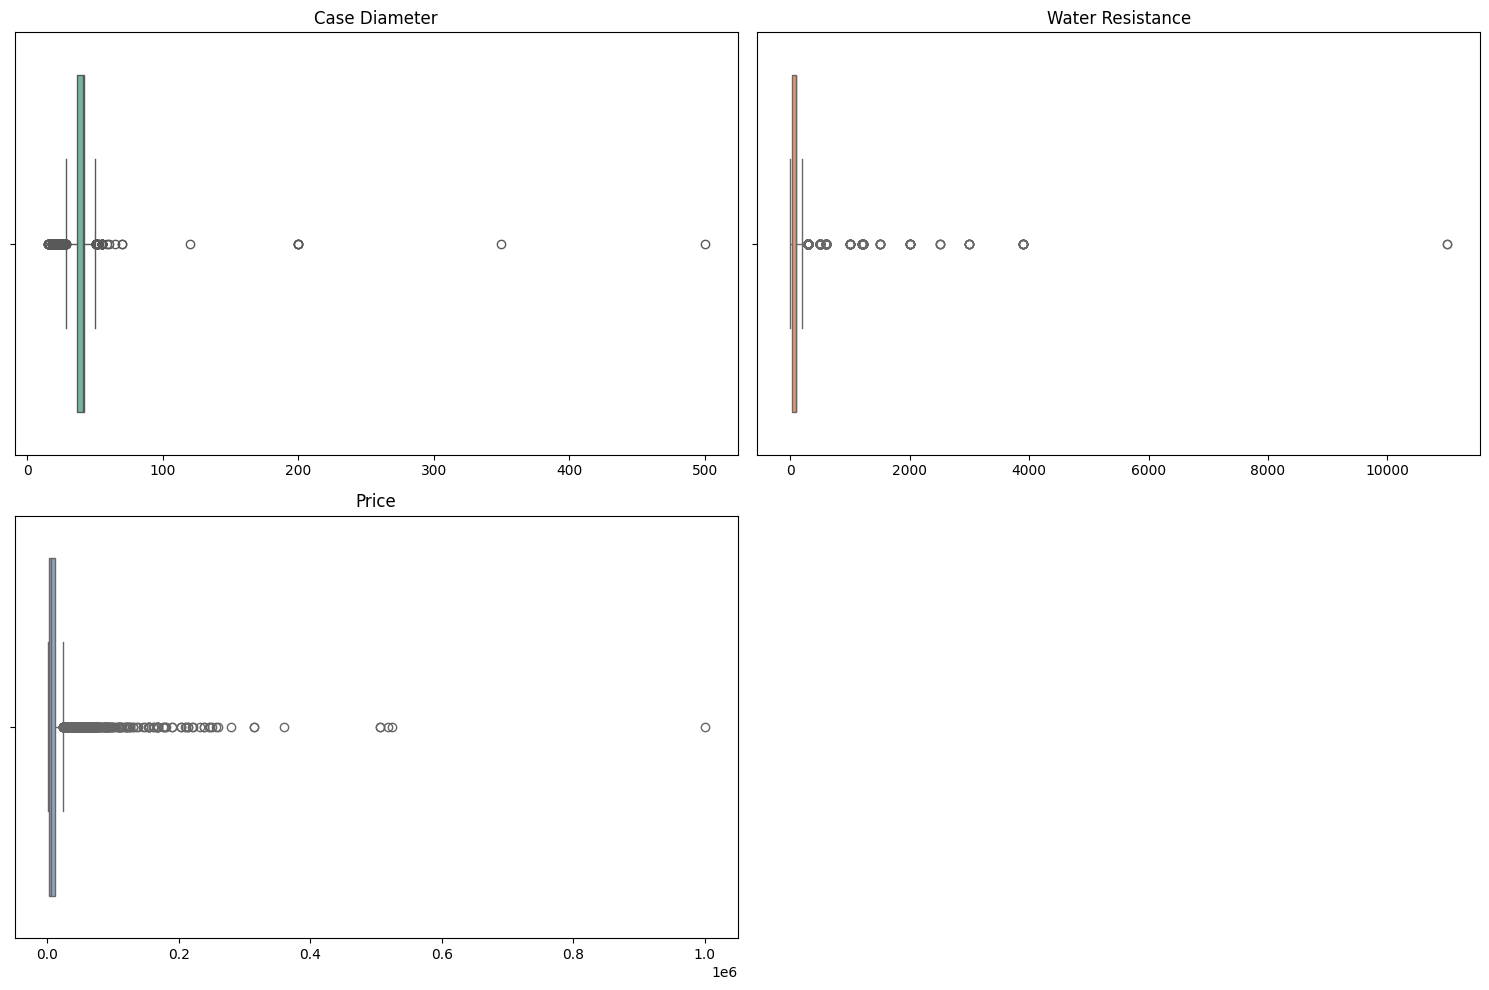

In [6]:
palette = sns.color_palette("Set2", n_colors=len(num_cols))

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[col], color=palette[i])
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

**1. Biểu đồ "Case Diameter" (Đường kính vỏ)**
- Đường trung vị (**Median** - đường kẻ trong hộp): Đường trung vị nằm ở một giá trị khá nhỏ, cho thấy phần lớn các đồng hồ có đường kính vỏ nhỏ.
- Hộp (**Box**): Hộp rất hẹp và tập trung ở phía bên trái của biểu đồ, điều này có nghĩa là phần lớn dữ liệu tập trung rất chặt chẽ xung quanh đường trung vị. Điều này cho thấy sự đồng nhất cao ở các giá trị đường kính vỏ thấp.
- Râu (**Whiskers**): Các râu cũng khá ngắn, đặc biệt là râu bên phải, nhưng vẫn có các điểm dữ liệu nằm ngoài râu.
- Giá trị ngoại lệ (**Outliers** - các chấm tròn): Có rất nhiều chấm tròn nằm rải rác về phía bên phải, cho thấy một lượng đáng kể các giá trị ngoại lệ có đường kính vỏ lớn hơn nhiều so với phần lớn dữ liệu. Những giá trị này kéo dài đến gần 500, xác nhận nhận định từ biểu đồ histogram trước đó.
- Nhận xét bổ sung: Sự tập trung lớn của dữ liệu ở các giá trị thấp và nhiều ngoại lệ ở phía cao cho thấy phân bố lệch phải rất rõ rệt.

**2. Biểu đồ "Water Resistance" (Khả năng chống nước)**
- Đường trung vị (**Median**): Đường trung vị nằm rất gần 0. Điều này chỉ ra rằng hơn một nửa số đồng hồ có khả năng chống nước rất thấp hoặc không đáng kể.
- Hộp (**Box**): Hộp cực kỳ hẹp và nằm sát 0, cho thấy phần lớn dữ liệu khả năng chống nước tập trung rất chặt chẽ ở các giá trị rất thấp (gần như 0).
- Râu (**Whiskers**): Râu bên phải ngắn, nhưng cũng có các điểm dữ liệu nằm ngoài râu.
- Giá trị ngoại lệ (**Outliers**): Tương tự như "Case Diameter", có rất nhiều chấm tròn nằm rải rác về phía bên phải, kéo dài đến hơn 10000. Điều này xác nhận rằng có một số lượng đáng kể các sản phẩm có khả năng chống nước cực kỳ cao, là các giá trị ngoại lệ so với phần lớn dữ liệu.
- Nhận xét bổ sung: Phân bố này cực kỳ lệch phải, cho thấy phần lớn các sản phẩm không tập trung vào tính năng chống nước cao, trong khi một số ít lại có khả năng chống nước vượt trội.

**3. Biểu đồ "Price" (Giá)**
- Đường trung vị (**Median**): Đường trung vị nằm ở một giá trị rất thấp (có thể dưới 20000), điều này cho thấy đa số các sản phẩm có giá phải chăng.
- Hộp (**Box**): Hộp rất hẹp và nằm gần 0, cho thấy phần lớn các sản phẩm có giá nằm trong một khoảng rất hẹp và thấp.
- Râu (**Whiskers**): Râu bên phải cũng khá ngắn so với tổng phạm vi dữ liệu.
- Giá trị ngoại lệ (**Outliers**): Có một lượng lớn các chấm tròn rải rác về phía bên phải, kéo dài đến hơn 250000. Điều này cho thấy có một số lượng đáng kể các sản phẩm có giá rất cao, là các giá trị ngoại lệ.
- Nhận xét bổ sung: Phân bố của "Price" cũng rất lệch phải, xác nhận rằng thị trường có nhiều sản phẩm giá rẻ, trong khi phân khúc cao cấp hoặc xa xỉ chiếm một phần nhỏ nhưng có giá trị rất lớn.

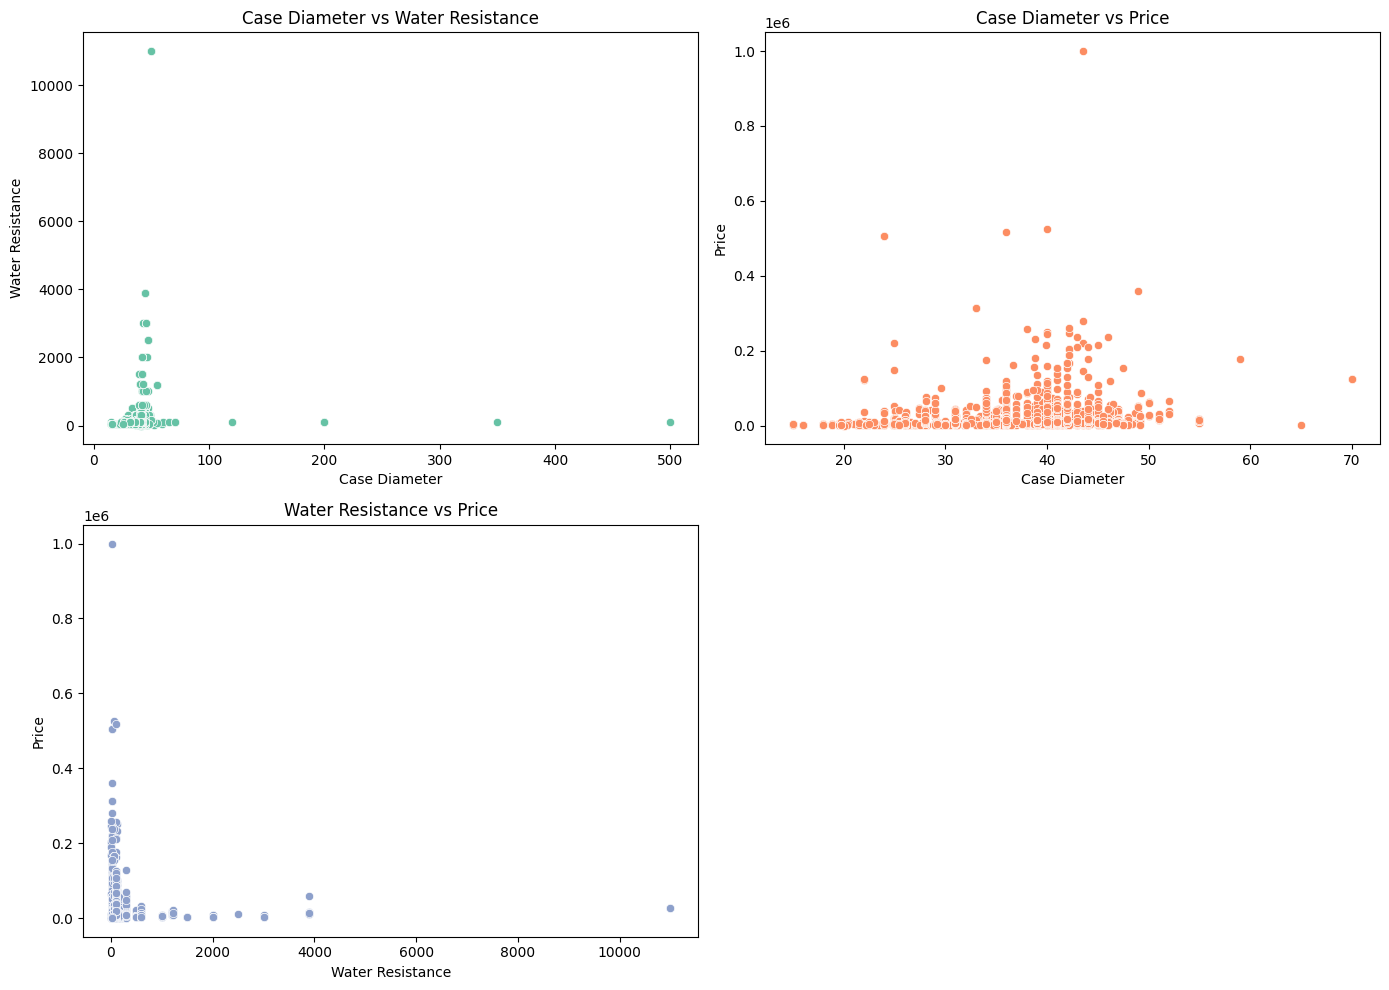

In [7]:
import itertools
import math

pairs = list(itertools.combinations(num_cols, 2))
n = len(pairs)
cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 7, rows * 5))

colors = sns.color_palette("Set2", n_colors=n)

for idx, (x, y) in enumerate(pairs, start=1):
    plt.subplot(rows, cols, idx)
    sns.scatterplot(data=df, x=x, y=y, color=colors[idx - 1])
    plt.title(f'{x} vs {y}')

plt.tight_layout()
plt.show()

**- Nhận xét:**
  - Phân bố lệch phải nghiêm trọng: Tất cả các biến có phân bố lệch phải rất mạnh, với phần lớn dữ liệu tập trung ở các giá trị thấp.
  - Giá trị ngoại lệ đáng kể: Cả ba biến đều có một lượng lớn các giá trị ngoại lệ ở phía trên (giá trị cao), kéo dài phạm vi dữ liệu và cho thấy các phân khúc sản phẩm đặc biệt (ví dụ: kích thước lớn, khả năng chống nước cực cao, giá xa xỉ).

**- Hướng khai phá dữ liệu:**
- Xử lý và phân tích ngoại lệ: Nghiên cứu kỹ các giá trị ngoại lệ. Chúng có phải là lỗi không, hay đại diện cho các phân khúc sản phẩm quan trọng (ví dụ: đồng hồ lặn chuyên dụng, đồng hồ cao cấp)? Quyết định giữ lại, loại bỏ, hoặc biến đổi.
- Biến đổi dữ liệu: Áp dụng các phép biến đổi (ví dụ: logarit) cho các biến lệch phải ("Price", "Water Resistance", "Case Diameter") để làm cho phân bố gần đối xứng hơn, cải thiện hiệu suất của các mô hình thống kê.
- Phân loại/Phân nhóm:
  - Phân khúc giá: Chia "Case Diameter" thành các cấp độ định tính (ví dụ: S, M,L) để phân tích đặc điểm của từng nhóm.
  - Phân loại chống nước: Chuyển "Water Resistance" thành các cấp độ định tính (ví dụ: không chống nước, đi mưa, đi bơi, lặn).
  - Phân nhóm sản phẩm: Sử dụng thuật toán phân nhóm (clustering) để xác định các nhóm sản phẩm tự nhiên dựa trên các thuộc tính này.

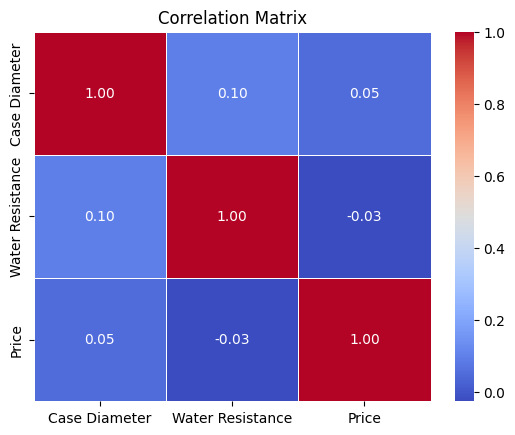

In [14]:
numeric_df = df[num_cols]
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

**Nhận xét:**
- Ma trận tương quan này xác nhận rằng không có mối quan hệ tuyến tính mạnh mẽ nào giữa bất kỳ cặp biến nào trong số "Case Diameter", "Water Resistance" và "Price". Điều này đặc biệt đúng với "Water Resistance" và "Price", nơi biểu đồ phân tán cho thấy một mối quan hệ phức tạp, phi tuyến tính và có thể có nhiều phân khúc dữ liệu khác nhau, mà hệ số tương quan Pearson không thể nắm bắt được.

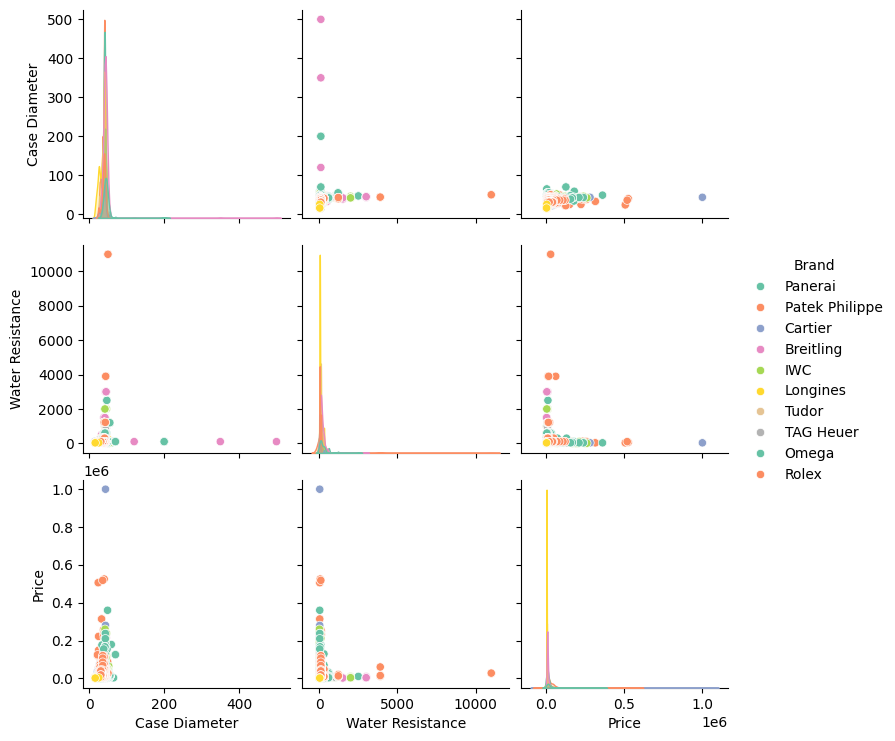

In [9]:
sns.pairplot(df, vars=num_cols, hue='Brand', palette='Set2')
plt.show()

##### Overall Conclusion

- Dữ liệu thô và nhiều ngoại lệ: Biểu đồ một lần nữa nhấn mạnh rằng dữ liệu "thô" (raw data) có nhiều giá trị ngoại lệ và phân bố rất lệch, điều này cần được xem xét cẩn thận trong các phân tích tiếp theo (ví dụ: tiền xử lý dữ liệu, biến đổi, hoặc sử dụng các mô hình robust).
- Mối quan hệ phức tạp và phân khúc: Mối quan hệ giữa các biến không đơn giản là tuyến tính. Có vẻ như tồn tại các phân khúc sản phẩm khác nhau với các đặc điểm giá và tính năng riêng biệt.
- Giá bị ảnh hưởng bởi nhiều yếu tố: Giá cả dường như không chỉ phụ thuộc vào "Case Diameter" hay "Water Resistance" một cách đơn giản, mà còn bởi các yếu tố khác không có trong tập dữ liệu này (ví dụ: thương hiệu, vật liệu, độ phức tạp của bộ máy, tính năng thông minh, v.v.). Điều này đặc biệt rõ ràng với những sản phẩm giá rất cao nhưng khả năng chống nước thấp.

### Categorical Data Analysis

##### EDA

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\616678079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette="Set3")


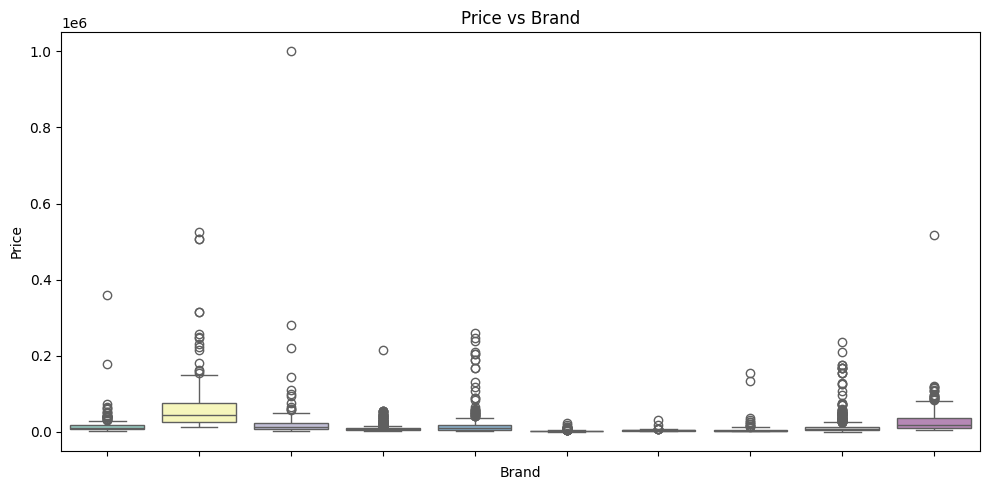

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\616678079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette="Set3")


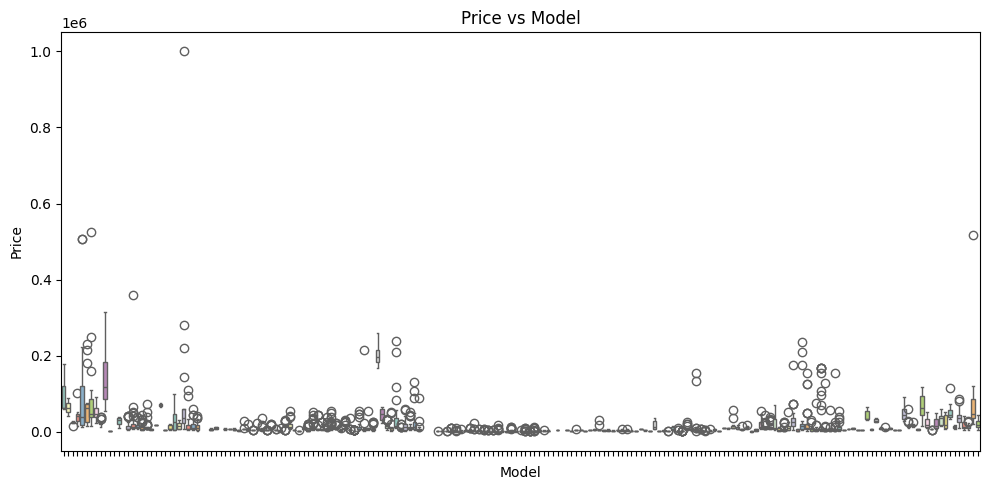

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\616678079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette="Set3")


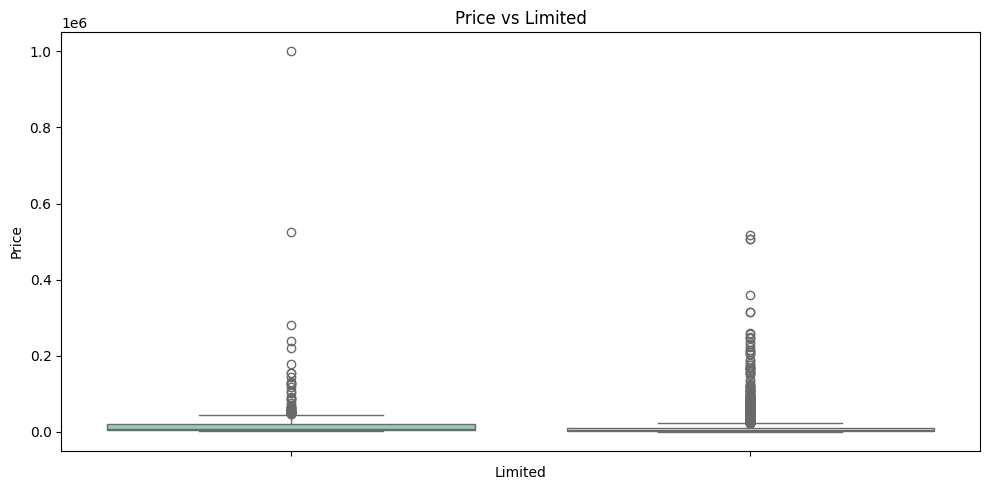

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\616678079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette="Set3")


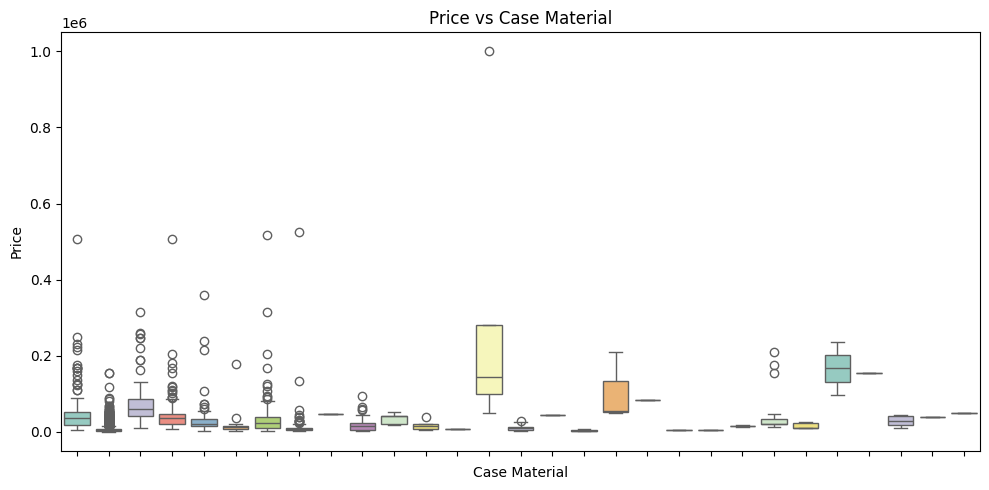

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\616678079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette="Set3")


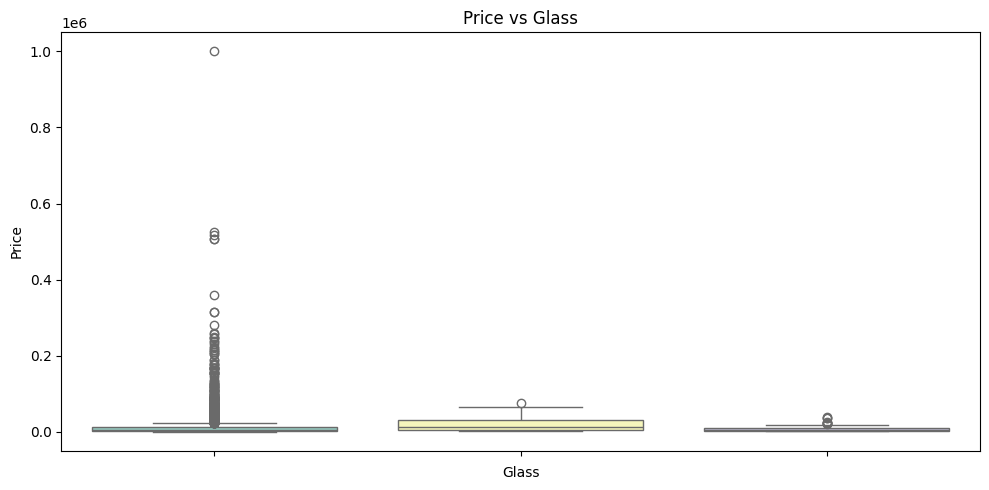

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\616678079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette="Set3")


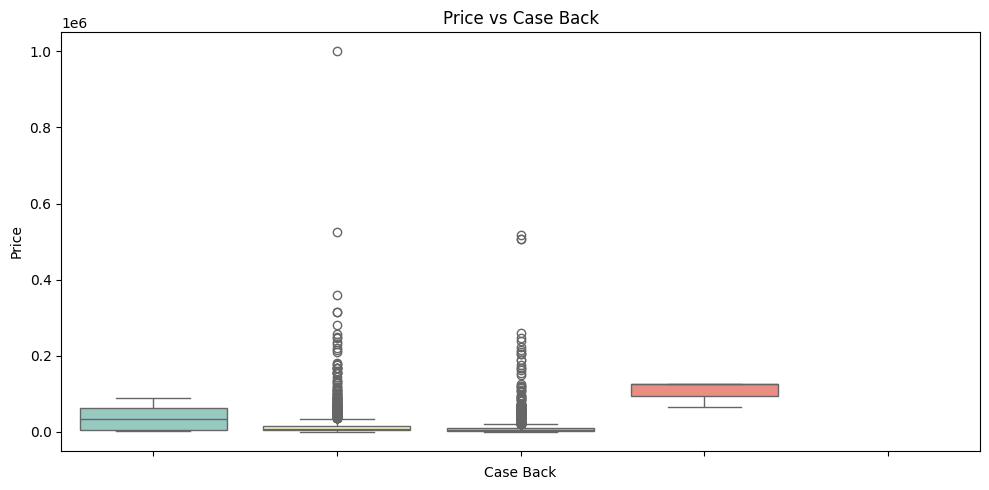

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\616678079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette="Set3")


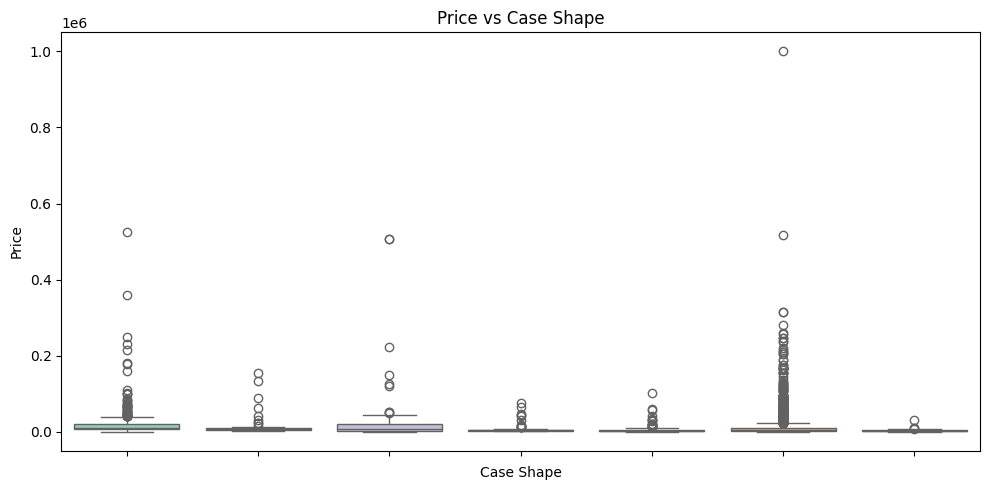

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\616678079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette="Set3")


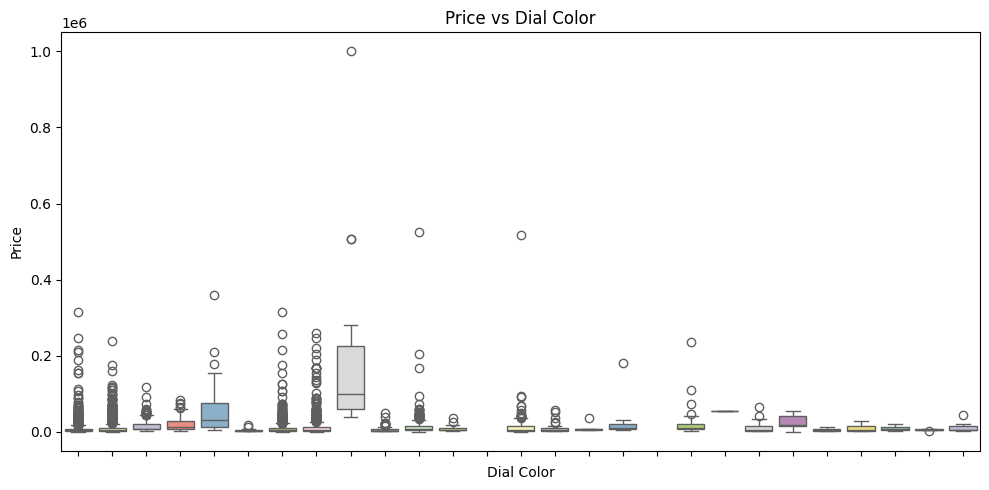

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\616678079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette="Set3")


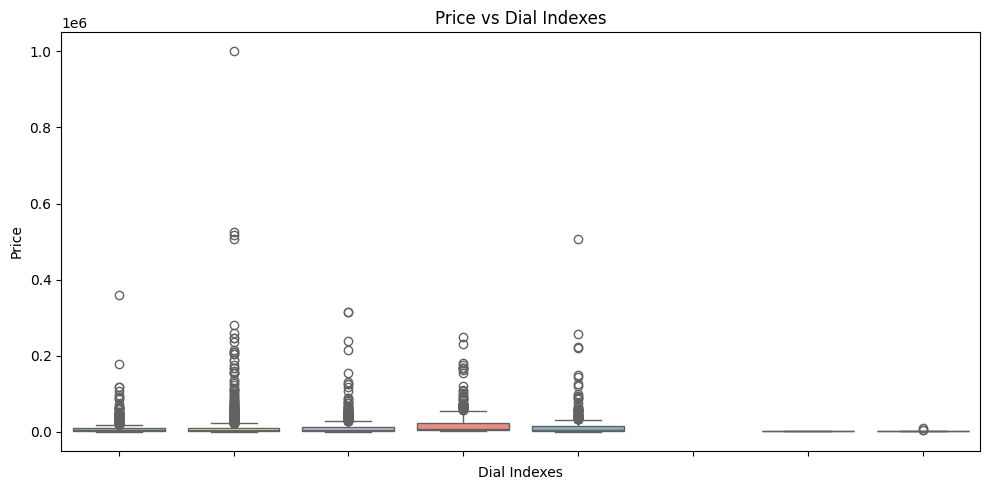

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\616678079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette="Set3")


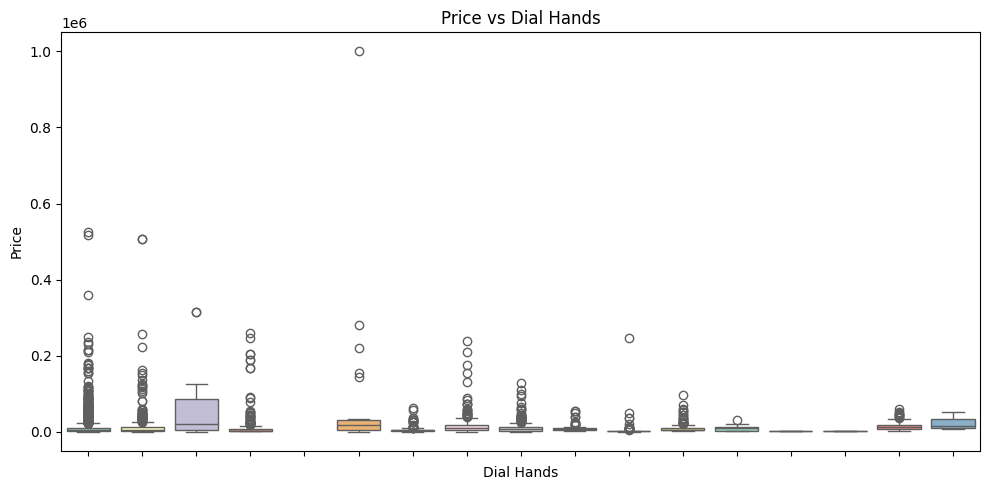

In [10]:
for i, col in enumerate(cat_cols, 1):
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col], y=df['Price'], palette="Set3")
    plt.title(f'Price vs {col}')
    plt.xticks(ticks=plt.xticks()[0], labels=[''] * len(plt.xticks()[0])) 

    plt.tight_layout()
    plt.show()

**1. Biểu đồ "Price vs Brand" (Giá theo Thương hiệu)**

**- Nhận xét:**
  - Sự đa dạng về giá giữa các thương hiệu: Có sự khác biệt rất lớn về phân bố giá giữa các thương hiệu khác nhau. Một số thương hiệu có giá trung bình thấp (hộp nằm gần 0), trong khi các thương hiệu khác có giá trung bình cao hơn và/hoặc phạm vi giá rộng hơn.
  - Thương hiệu cao cấp/xa xỉ: Có một số thương hiệu rõ ràng có giá cao hơn đáng kể và nhiều giá trị ngoại lệ ở mức giá rất cao (ví dụ: một thương hiệu có giá trung vị quanh 50000-60000 và các ngoại lệ lên đến hơn 150000, hoặc một thương hiệu khác với ngoại lệ trên 250000). Điều này cho thấy vai trò cực kỳ quan trọng của thương hiệu trong việc định giá sản phẩm.
  - Thương hiệu phổ thông: Nhiều thương hiệu có hộp và đường trung vị rất thấp (gần 0), cho thấy chúng tập trung vào phân khúc giá phổ thông.
  - Phạm vi giá rộng: Một số thương hiệu có phạm vi giá rất rộng (chiều cao của hộp lớn và/hoặc râu dài), cho thấy họ có thể sản xuất nhiều loại sản phẩm từ phổ thông đến cao cấp.

**- Kết luận:** Thương hiệu là một yếu tố ảnh hưởng cực kỳ quan trọng đến giá cả. Có những thương hiệu định vị ở phân khúc cao cấp, thể hiện qua giá trung vị cao và sự xuất hiện của nhiều sản phẩm giá trị ngoại lệ đắt đỏ.

**2. Biểu đồ "Price vs Model" (Giá theo Mẫu mã)**

**- Nhận xét:**
  - Quá nhiều mẫu mã: Biểu đồ hiển thị quá nhiều danh mục "Model" trên trục X, khiến việc đọc và so sánh cụ thể từng mẫu trở nên khó khăn. Tuy nhiên, có thể thấy rõ rằng có hàng trăm mẫu mã khác nhau.
  - Sự phân tán giá theo mẫu mã: Tương tự như thương hiệu, mỗi mẫu mã có phân bố giá riêng. Một số mẫu mã có giá rất thấp, trong khi một số khác có giá trung bình cao hơn và/hoặc nhiều giá trị ngoại lệ đắt tiền.
  - Mẫu mã "đắt đỏ": Một số mẫu mã nổi bật với đường trung vị cao và/hoặc các giá trị ngoại lệ cực kỳ cao (ví dụ: một mẫu mã có giá trung vị khoảng 200000, hoặc các mẫu mã khác có ngoại lệ trên 250000).
  - Đa dạng giá trong cùng một mẫu: Một số mẫu mã có hộp rất hẹp và râu ngắn, cho thấy giá cả khá đồng nhất, trong khi những mẫu khác có phạm vi giá rất rộng, có thể do các biến thể khác nhau của cùng một mẫu.

**- Kết luận:** Mẫu mã cũng là một yếu tố quan trọng ảnh hưởng đến giá. Tuy nhiên, do số lượng mẫu mã quá lớn, việc phân tích cụ thể từng mẫu đòi hỏi cách tiếp cận khác (ví dụ: nhóm các mẫu mã theo đặc điểm hoặc sử dụng mô hình học máy).

**3. Biểu đồ "Price vs Limited" (Giá theo Phiên bản giới hạn)**

**- Nhận xét:**
  - Phân khúc giá phiên bản "Không giới hạn": Hộp của nhóm này nằm rất gần 0, cho thấy phần lớn các sản phẩm không giới hạn có giá rất thấp. Có một số ngoại lệ giá cao, nhưng phạm vi trung vị và IQR (phạm vi nội tứ phân vị) rất hẹp.
  - Phân khúc giá phiên bản "Có giới hạn": Hộp của nhóm này cũng nằm gần 0, cho thấy có nhiều sản phẩm giới hạn giá thấp. TUY NHIÊN, nhóm "Có giới hạn" có rất nhiều giá trị ngoại lệ kéo dài đến mức giá cực kỳ cao (hơn 250000). Điều này cho thấy mặc dù không phải tất cả các sản phẩm giới hạn đều đắt, nhưng khả năng là phiên bản giới hạn làm tăng đáng kể tiềm năng đạt được mức giá rất cao.

**- Kết luận:** Việc là phiên bản giới hạn không đảm bảo giá cao, nhưng nó là một yếu tố mạnh mẽ góp phần tạo ra các sản phẩm có giá trị cực kỳ cao, thể hiện qua sự xuất hiện dày đặc của các ngoại lệ giá cao ở nhóm này.

**4. Biểu đồ "Price vs Case Material" (Giá theo Vật liệu vỏ)**

**- Nhận xét:**
  - Sự đa dạng về vật liệu: Có rất nhiều loại vật liệu vỏ khác nhau (được biểu thị bằng các nhóm trên trục X).
  - Ảnh hưởng của vật liệu đến giá: Một số vật liệu rõ ràng liên quan đến các sản phẩm có giá cao hơn. Ví dụ, một số nhóm vật liệu có đường trung vị cao và/hoặc nhiều ngoại lệ giá cao (ví dụ: nhóm thứ 2 từ trái sang có đường trung vị cao và nhiều ngoại lệ, hoặc nhóm gần cuối bên phải cũng có giá trung vị cao).
  - Vật liệu phổ thông/giá rẻ: Nhiều loại vật liệu có hộp và đường trung vị rất thấp (gần 0), cho thấy chúng được sử dụng cho các sản phẩm giá phổ thông.
  - Sự biến thiên lớn: Trong cùng một loại vật liệu, giá có thể biến động rất lớn, thể hiện qua chiều cao của hộp và số lượng ngoại lệ.

**- Kết luận:** Vật liệu vỏ là một yếu tố quan trọng khác ảnh hưởng đến giá. Các vật liệu cao cấp hoặc quý hiếm rõ ràng tương quan với giá cao hơn, nhưng cũng có sự đa dạng về giá ngay cả trong cùng một loại vật liệu.

**5. Biểu đồ "Price vs Glass" (Giá theo Loại kính)**

**- Nhận xét:**
  - Các loại kính phổ biến: Biểu đồ hiển thị ba nhóm chính của loại kính (có thể là Mineral, Sapphire, Acrylic hoặc tương tự).
  - Phân bố giá của loại kính đầu tiên: Hộp của loại kính này (phía bên trái) rất hẹp và nằm gần 0, cho thấy phần lớn các đồng hồ sử dụng loại kính này có giá rất thấp. Tuy nhiên, đặc điểm nổi bật là có rất nhiều giá trị ngoại lệ kéo dài đến mức giá cực kỳ cao (trên 250.000). Điều này gợi ý rằng loại kính này có thể là kính Sapphire (hoặc một loại kính cao cấp khác) – một vật liệu cao cấp được sử dụng rộng rãi, không chỉ trên đồng hồ giá rẻ mà còn trên các sản phẩm xa xỉ nhất.
  - Phân bố giá của loại kính thứ hai: Hộp của loại kính này (giữa) rộng hơn một chút so với loại đầu tiên và cũng tập trung ở phân khúc giá thấp đến tầm trung. Có ít giá trị ngoại lệ hơn và các giá trị này cũng không cao bằng loại đầu tiên (chỉ khoảng 80.000).
  - Phân bố giá của loại kính thứ ba: Hộp của loại kính này (phía bên phải) khá hẹp và nằm ở mức giá thấp nhất trong ba loại. Nó có rất ít giá trị ngoại lệ và các giá trị này không cao (chỉ khoảng 40.000). Điều này có thể là kính Mineral hoặc Acrylic.

**- Kết luận:** Loại kính là một yếu tố có ảnh hưởng đến giá, nhưng không phải là yếu tố duy nhất. Loại kính đầu tiên đặc biệt quan trọng vì nó liên quan đến tiềm năng đạt được mức giá cực kỳ cao, đồng thời vẫn phổ biến ở phân khúc giá thấp. Điều này cho thấy loại kính cao cấp có thể là tiêu chuẩn trong nhiều phân khúc giá, nhưng các yếu tố khác mới là động lực chính của giá trị xa xỉ.

**6. Biểu đồ "Price vs Case Back" (Giá theo Loại nắp lưng)**

**- Nhận xét:**
  - Các loại nắp lưng: Biểu đồ hiển thị nhiều nhóm nắp lưng khác nhau (có thể là Solid, Exhibition, Screw-down, Snap-on, v.v.).
  - Sự đa dạng về giá theo loại nắp lưng: Có sự khác biệt rõ ràng về phân bố giá giữa các loại nắp lưng.
  - Loại nắp lưng phổ biến/giá thấp: Nhiều loại nắp lưng có hộp và đường trung vị rất thấp (gần 0), cho thấy chúng phổ biến trên các sản phẩm giá phải chăng (ví dụ: các nhóm nắp lưng thứ hai, thứ ba từ trái sang).
  - Loại nắp lưng cao cấp/giá cao: Một số loại nắp lưng (đặc biệt là nhóm đầu tiên từ trái sang và nhóm thứ tư từ phải sang) có đường trung vị cao hơn đáng kể và/hoặc xuất hiện nhiều giá trị ngoại lệ ở mức giá rất cao (trên 100.000, thậm chí vượt 250.000).
  - Điểm đáng chú ý: Đặc biệt, nhóm nắp lưng đầu tiên (từ trái sang) có đường trung vị khá cao (khoảng 20.000-30.000) và một lượng lớn các ngoại lệ giá trị cao. Nhóm nắp lưng thứ tư từ phải sang có đường trung vị rất cao (khoảng 60.000) và các ngoại lệ lên đến hơn 250.000, đây có thể là loại nắp lưng đặc biệt liên quan đến đồng hồ cao cấp.
  - Phạm vi giá trong cùng loại: Trong cùng một loại nắp lưng, giá cũng có thể biến động đáng kể, cho thấy sự ảnh hưởng tổng hòa của nhiều yếu tố khác.

**- Kết luận:** Loại nắp lưng là một yếu tố quan trọng ảnh hưởng đến giá, đặc biệt là các loại nắp lưng đặc biệt có thể định vị sản phẩm ở phân khúc cao cấp hơn. Điều này gợi ý rằng thiết kế và tính năng của nắp lưng cũng đóng góp vào giá trị tổng thể của đồng hồ.

**7. Biểu đồ "Price vs Case Shape" (Giá theo Hình dạng vỏ)**

**- Nhận xét:**
  - Sự đa dạng về hình dạng vỏ: Biểu đồ hiển thị một số loại hình dạng vỏ khác nhau (được biểu thị bằng các nhóm trên trục X).
  - Ảnh hưởng của hình dạng vỏ đến giá: Có sự khác biệt trong phân bố giá giữa các hình dạng vỏ khác nhau, mặc dù không phải lúc nào cũng rõ rệt bằng "Brand" hay "Case Material".
  - Hình dạng phổ biến/giá thấp: Nhiều hình dạng vỏ có hộp và đường trung vị rất thấp (gần 0), cho thấy chúng là những hình dạng phổ biến và thường xuất hiện ở các sản phẩm giá phải chăng.
  - Hình dạng với tiềm năng giá cao: Một số hình dạng nhất định (ví dụ: nhóm thứ hai từ trái sang, hoặc nhóm thứ hai từ phải sang) có đường trung vị cao hơn và/hoặc nhiều giá trị ngoại lệ ở mức giá cao (trên 100.000, thậm chí vượt 250.000). Điều này gợi ý rằng các hình dạng này có thể liên quan đến các thiết kế độc đáo, phức tạp hoặc được ưa chuộng trong phân khúc cao cấp.
  - Hình dạng chiếm ưu thế ở phân khúc giá cao: Đáng chú ý là nhóm hình dạng thứ ba từ phải sang có rất nhiều giá trị ngoại lệ kéo dài đến hơn 250.000, đồng thời hộp vẫn nằm ở mức giá thấp. Điều này có nghĩa là hình dạng đó rất phổ biến ở cả phân khúc giá rẻ, nhưng cũng là hình dạng được sử dụng cho các sản phẩm siêu xa xỉ. Đây có thể là hình tròn hoặc hình chữ nhật, là những hình dạng kinh điển.
  - Phạm vi giá trong cùng hình dạng: Tương tự như các biến phân loại khác, ngay cả trong cùng một hình dạng vỏ, giá cũng có thể biến động đáng kể, cho thấy sự ảnh hưởng tổng hòa của nhiều yếu tố khác.

**- Kết luận:** Hình dạng vỏ là một yếu tố có ảnh hưởng đến giá, đặc biệt là một số hình dạng nhất định có tiềm năng liên quan đến các sản phẩm cao cấp hoặc xa xỉ. Tuy nhiên, nó dường như không phải là yếu tố quyết định giá mạnh mẽ bằng "Thương hiệu" hay "Vật liệu vỏ".

**8. Biểu đồ "Price vs Dial Color" (Giá theo Màu mặt số)**

**- Nhận xét:**
  - Sự đa dạng về màu mặt số: Biểu đồ hiển thị rất nhiều màu mặt số khác nhau (được biểu thị bằng các nhóm trên trục X).
  - Ảnh hưởng của màu mặt số đến giá: Có sự khác biệt đáng kể về phân bố giá giữa các màu mặt số khác nhau.
  - Màu sắc phổ biến/giá thấp: Nhiều màu mặt số có hộp và đường trung vị rất thấp (gần 0), cho thấy chúng là những màu sắc phổ biến và thường được sử dụng cho các sản phẩm giá phải chăng.
  - Màu sắc với tiềm năng giá cao: Một số màu mặt số (ví dụ: nhóm thứ ba, thứ tư từ trái sang, hoặc một số nhóm ở phía bên phải) có đường trung vị cao hơn đáng kể và/hoặc xuất hiện nhiều giá trị ngoại lệ ở mức giá rất cao (trên 100.000, thậm chí vượt 250.000). Điều này gợi ý rằng các màu sắc này có thể là những lựa chọn độc đáo, hiếm có, hoặc được ưa chuộng trong phân khúc cao cấp, hoặc liên quan đến các thương hiệu/dòng sản phẩm đắt tiền.
  - Màu sắc có phạm vi giá rất rộng: Một số màu mặt số có phạm vi giá rất rộng, bao gồm cả sản phẩm giá thấp và sản phẩm cực kỳ đắt tiền (thể hiện qua hộp thấp nhưng có nhiều ngoại lệ kéo dài rất xa). Điều này có thể xảy ra với các màu truyền thống như đen, trắng, xanh lam, được sử dụng rộng rãi trên nhiều phân khúc sản phẩm.
  - Sự phân tán dữ liệu: Nhìn chung, sự phân tán của các điểm dữ liệu (ngoại lệ) là rất lớn cho hầu hết các màu, cho thấy rằng màu mặt số cũng là một yếu tố quan trọng nhưng cần được xem xét cùng với các đặc điểm khác để dự đoán giá.

**- Kết luận:** Màu mặt số là một yếu tố quan trọng ảnh hưởng đến giá của đồng hồ. Một số màu sắc nhất định có thể là dấu hiệu của các sản phẩm ở phân khúc cao cấp, trong khi các màu phổ biến có thể xuất hiện ở mọi phân khúc, bao gồm cả những sản phẩm cực kỳ đắt tiền.

**9. Biểu đồ "Price vs Dial Indexes" (Giá theo Chỉ số mặt số / Dạng cọc số)**

**- Nhận xét:**
  - Sự đa dạng về chỉ số mặt số: Biểu đồ hiển thị nhiều loại chỉ số mặt số khác nhau (được biểu thị bằng các nhóm trên trục X). Mỗi nhóm đại diện cho một kiểu cọc số hoặc chỉ mục trên mặt đồng hồ (ví dụ: số Ả Rập, số La Mã, cọc số hình học, không số, v.v.).
  - Ảnh hưởng của chỉ số mặt số đến giá: Có sự khác biệt trong phân bố giá giữa các loại chỉ số mặt số khác nhau.
  - Chỉ số phổ biến/giá thấp: Nhiều loại chỉ số mặt số có hộp và đường trung vị rất thấp (gần 0), cho thấy chúng là những kiểu phổ biến và thường xuất hiện ở các sản phẩm giá phải chăng.
  - Chỉ số với tiềm năng giá cao: Một số loại chỉ số mặt số (ví dụ: nhóm thứ nhất, thứ hai, thứ ba, thứ tư từ trái sang, hoặc nhóm thứ năm từ phải sang) có nhiều giá trị ngoại lệ kéo dài đến mức giá rất cao (trên 150.000, thậm chí vượt 250.000). Điều này cho thấy rằng một số kiểu cọc số/chỉ số nhất định có thể liên quan đến các thiết kế cao cấp, độc đáo hoặc được ưa chuộng trong phân khúc đồng hồ đắt tiền.
  - Chỉ số có phạm vi giá rất rộng: Đặc biệt, nhóm chỉ số thứ tư từ trái sang có hộp rất hẹp và nằm ở mức giá thấp, nhưng lại có rất nhiều giá trị ngoại lệ kéo dài đến hơn 250.000. Điều này cho thấy đây có thể là một kiểu cọc số rất phổ biến, được sử dụng trên cả đồng hồ giá rẻ và những mẫu đồng hồ xa xỉ nhất.
  - Sự phân tán dữ liệu: Giống như các biến phân loại khác, sự phân tán của các điểm dữ liệu (ngoại lệ) là rất lớn cho hầu hết các nhóm, cho thấy rằng kiểu chỉ số mặt số cũng là một yếu tố quan trọng nhưng cần được xem xét cùng với các đặc điểm khác để dự đoán giá.

**- Kết luận:** Loại chỉ số mặt số là một yếu tố có ảnh hưởng đến giá của đồng hồ. Một số kiểu chỉ số nhất định có thể là đặc trưng của các sản phẩm ở phân khúc cao cấp, trong khi các kiểu phổ biến hơn có thể xuất hiện ở mọi phân khúc, bao gồm cả những sản phẩm cực kỳ đắt tiền.

**10. Biểu đồ "Price vs Dial Hands" (Giá theo Kim đồng hồ)**

**- Nhận xét:**
  - Đa dạng loại kim đồng hồ: Biểu đồ hiển thị rất nhiều loại kim đồng hồ khác nhau (được biểu thị bằng các nhóm trên trục X). Mỗi nhóm đại diện cho một kiểu dáng kim cụ thể (ví dụ: Dauphine, Baton, Alpha, Breguet, Skeleton, v.v.).
  - Ảnh hưởng của loại kim đồng hồ đến giá: Có sự khác biệt trong phân bố giá giữa các loại kim đồng hồ khác nhau, mặc dù không phải lúc nào cũng có sự tách biệt rõ ràng giữa các phân khúc giá.
  - Kim phổ biến/giá thấp: Nhiều loại kim đồng hồ có hộp và đường trung vị rất thấp (gần 0), cho thấy chúng là những kiểu phổ biến và thường được sử dụng cho các sản phẩm ở phân khúc giá phải chăng.
  - Kim với tiềm năng giá cao: Một số loại kim đồng hồ (ví dụ: nhóm đầu tiên từ trái sang, hoặc một số nhóm ở giữa biểu đồ) có nhiều giá trị ngoại lệ kéo dài đến mức giá rất cao (trên 150.000, thậm chí vượt 250.000). Điều này gợi ý rằng các kiểu kim này có thể liên quan đến các thiết kế đặc biệt, được sản xuất thủ công, hoặc được sử dụng trên các đồng hồ cao cấp.
  - Kiểu kim có phạm vi giá cực rộng: Đáng chú ý là nhóm kim đầu tiên từ trái sang có hộp và đường trung vị thấp, nhưng lại có rất nhiều giá trị ngoại lệ kéo dài đến hơn 250.000. Điều này chỉ ra rằng kiểu kim này có thể là một kiểu rất phổ biến (ví dụ: kim thẳng, kim dauphine cổ điển) được sử dụng rộng rãi trên cả đồng hồ giá rẻ và những mẫu đồng hồ xa xỉ nhất.
  - Sự phân tán dữ liệu: Tương tự như các biến phân loại khác, sự phân tán của các điểm dữ liệu (ngoại lệ) là rất lớn cho hầu hết các nhóm, cho thấy rằng kiểu kim đồng hồ cũng là một yếu tố quan trọng nhưng cần được xem xét cùng với các đặc điểm khác để dự đoán giá.

**- Kết luận:** Kiểu dáng kim đồng hồ là một yếu tố có ảnh hưởng đến giá của đồng hồ. Một số kiểu kim nhất định có thể là dấu hiệu của các sản phẩm ở phân khúc cao cấp, trong khi các kiểu phổ biến hơn có thể xuất hiện ở mọi phân khúc, bao gồm cả những sản phẩm cực kỳ đắt tiền. Yếu tố này đóng góp vào tính thẩm mỹ và đôi khi là sự phức tạp trong chế tác, từ đó ảnh hưởng đến giá trị.

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)
C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)


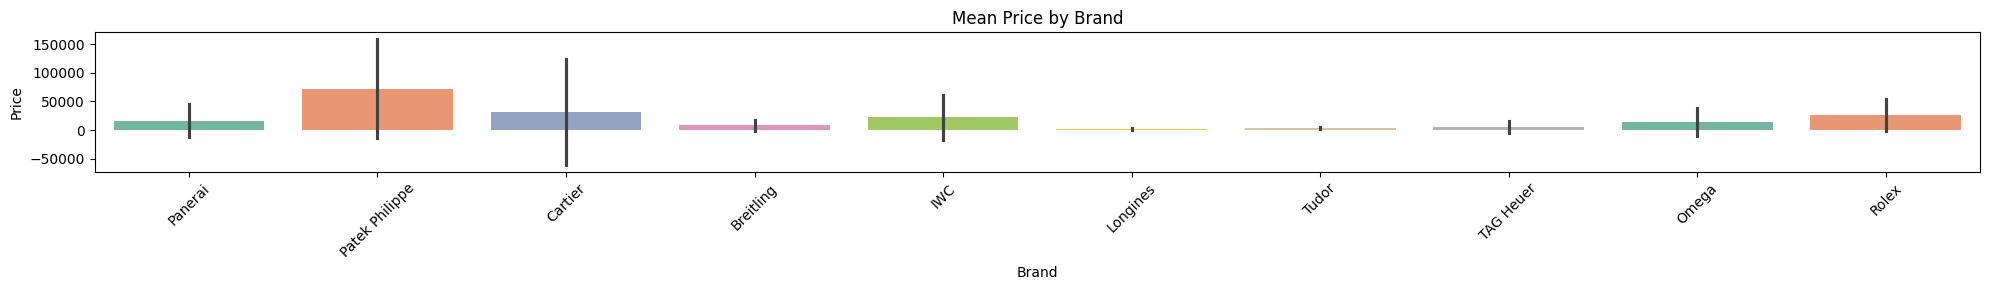

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)
C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)


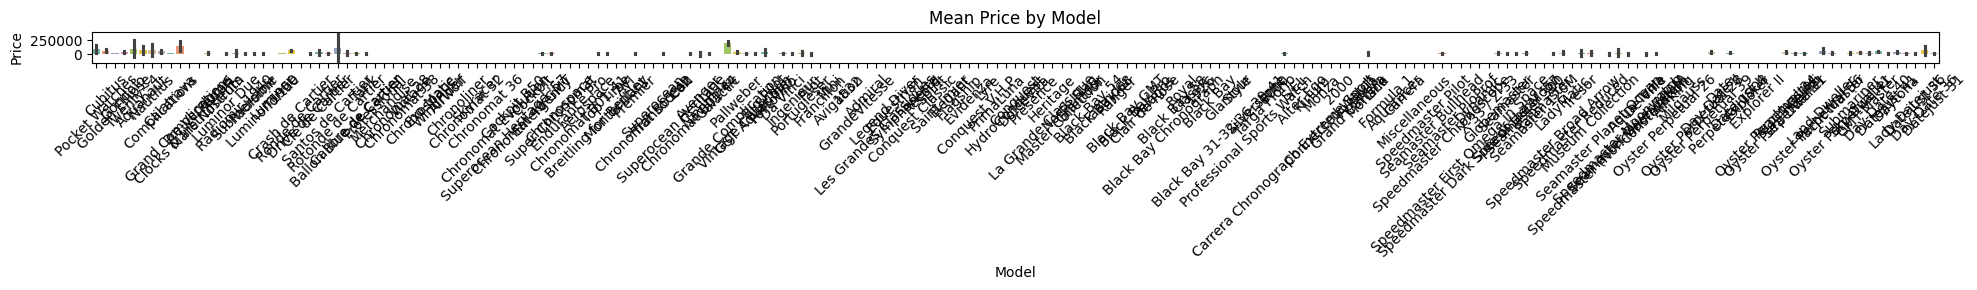

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)
C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)


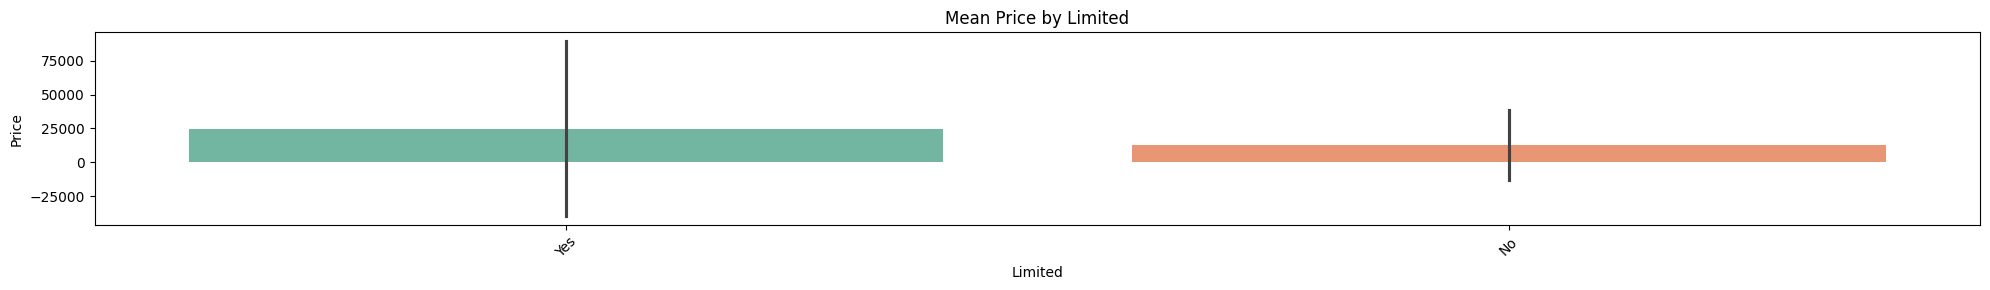

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)
C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)


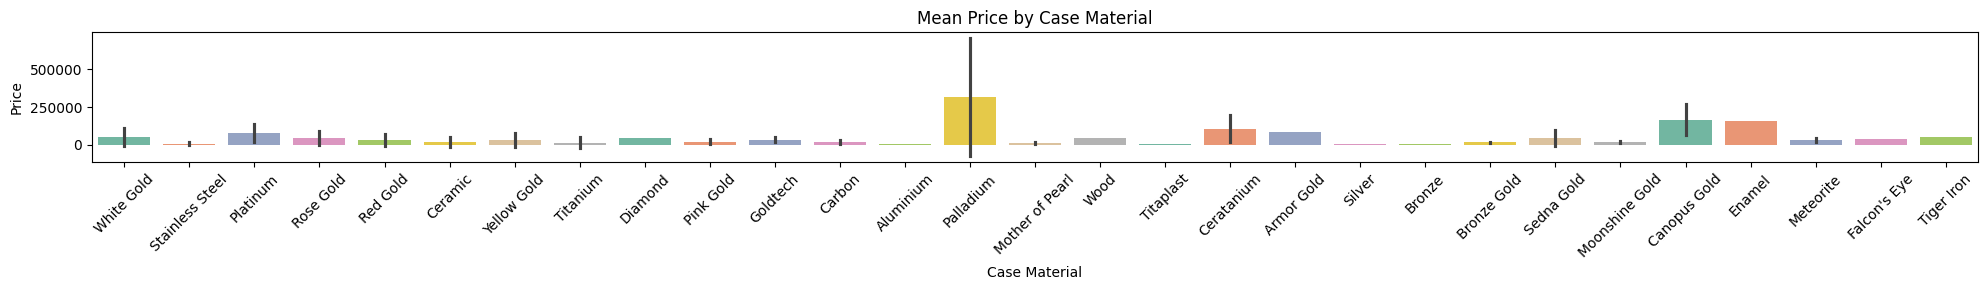

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)
C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)


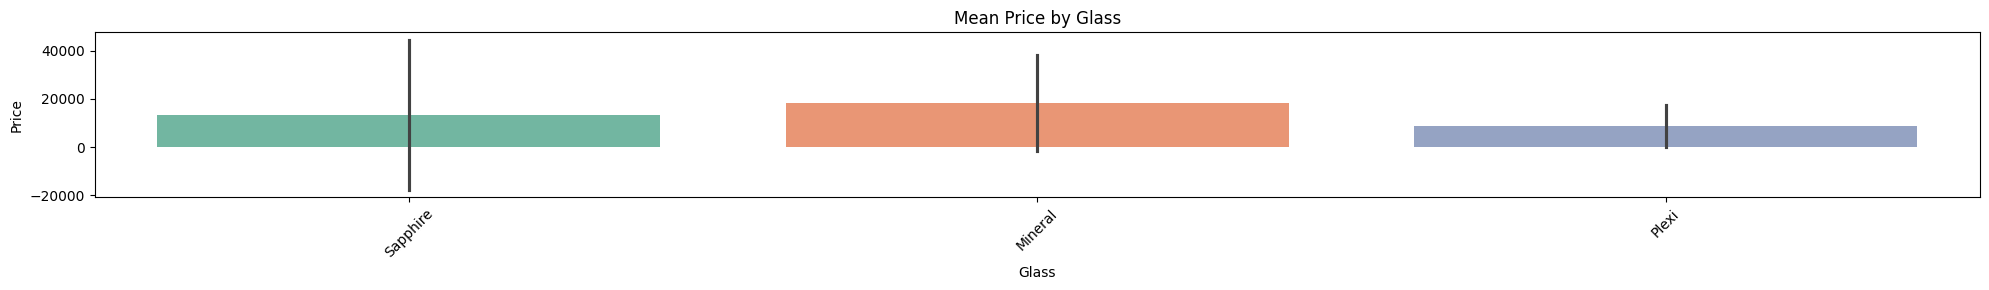

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)
C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)


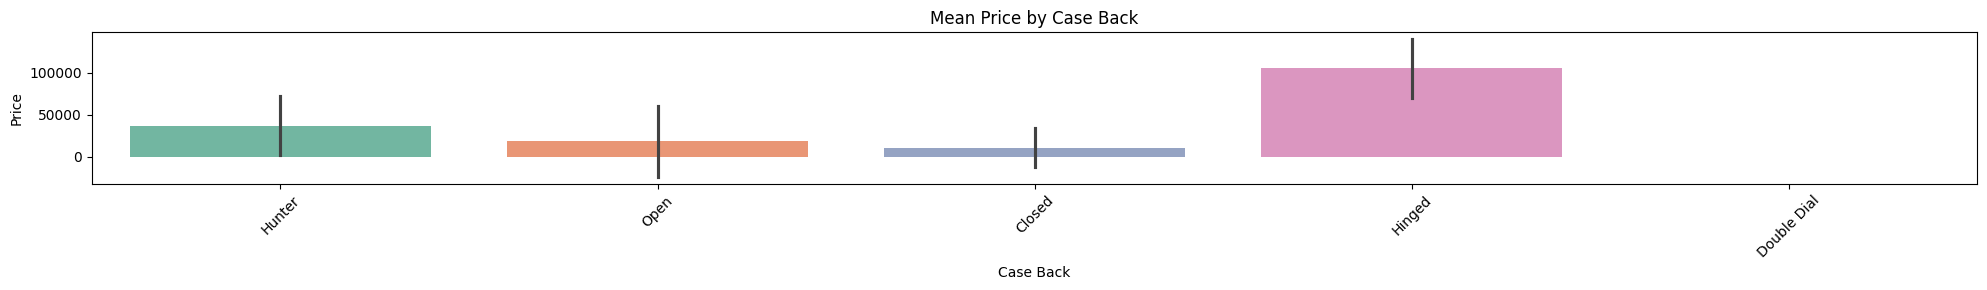

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)
C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)


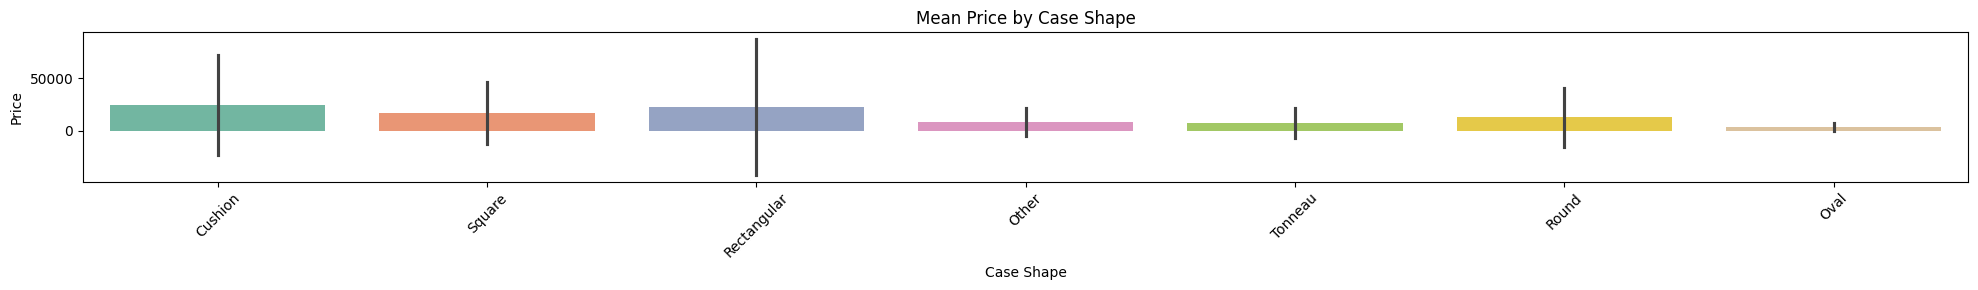

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)
C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)


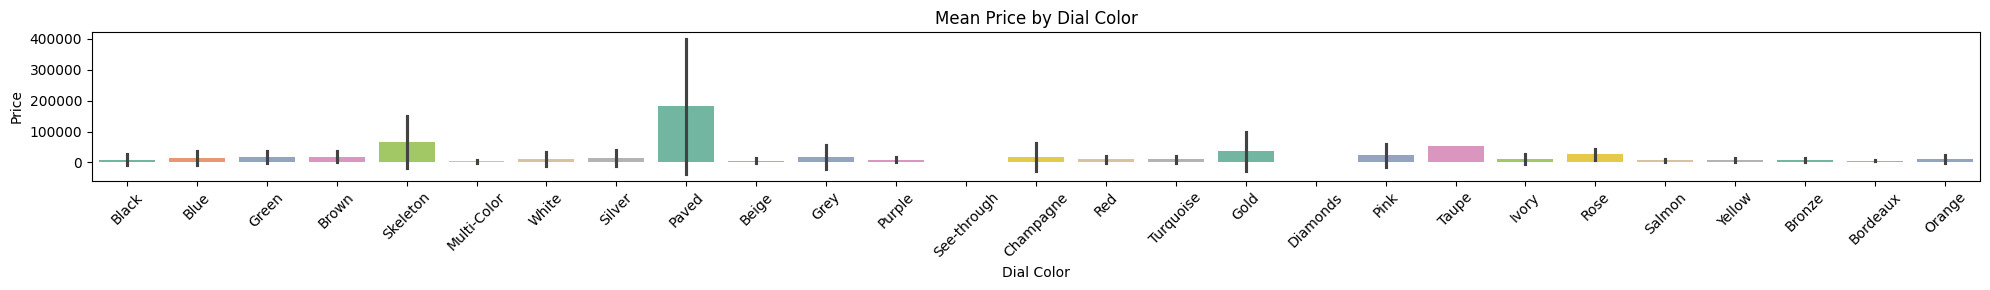

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)
C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)


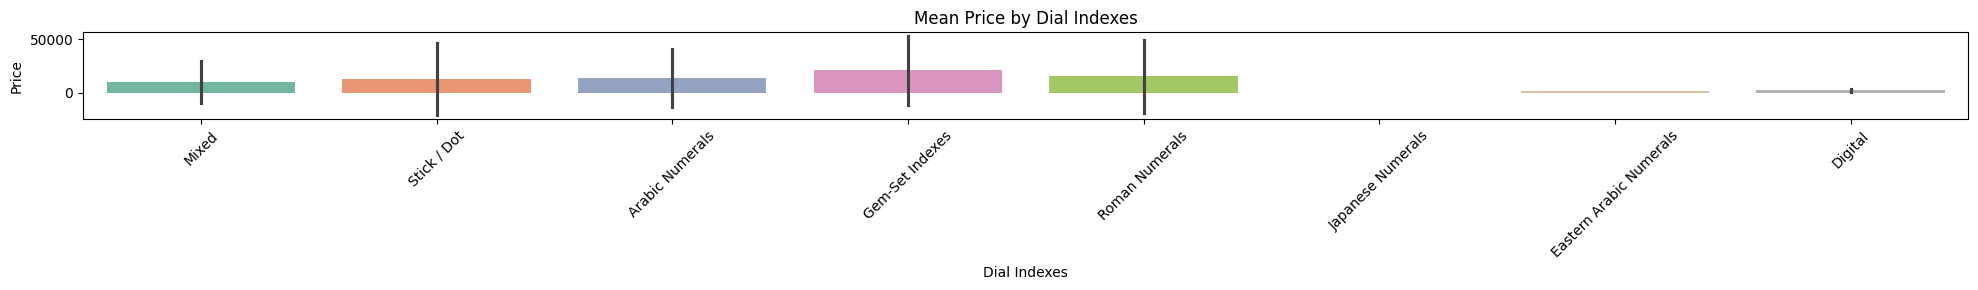

C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)
C:\Users\DELL\AppData\Local\Temp\ipykernel_4112\3302309814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)


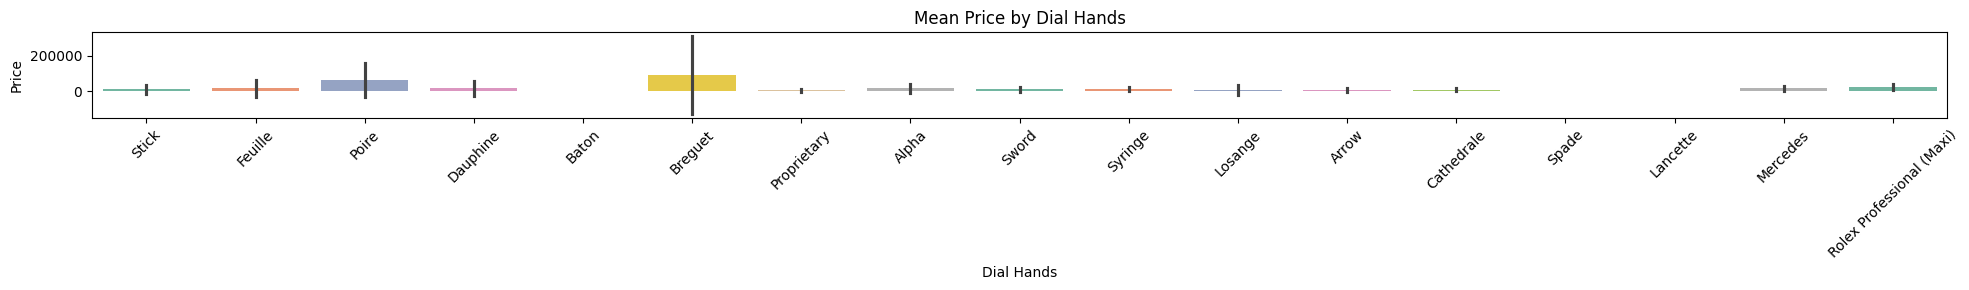

In [11]:
for col in cat_cols:
    unique_vals = df[col].nunique()
    palette = sns.color_palette("Set2", n_colors=unique_vals)

    plt.figure(figsize=(20, 3))
    sns.barplot(x=df[col], y=df['Price'], estimator='mean', ci='sd', palette=palette)
    plt.title(f'Mean Price by {col}')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


**1. Biểu đồ "Mean Price by Brand" (Giá trung bình theo Thương hiệu)**

**- Nhận xét:**
  - Thương hiệu quyết định giá: Có sự chênh lệch rất lớn về giá trung bình giữa các thương hiệu. Patek Philippe và IWC nổi bật với giá trung bình cao nhất, đồng thời có biên độ giá (thanh lỗi) rất rộng, cho thấy sự tồn tại của nhiều sản phẩm siêu đắt.
  - Phân khúc đa dạng: Các thương hiệu khác như Panerai, Cartier, Omega, Rolex nằm ở phân khúc giá trung bình thấp hơn nhưng vẫn có biến động giá. Longines, Tudor, TAG Heuer có giá trung bình thấp và ổn định hơn.
  - Giá trị ngoại lệ ảnh hưởng mạnh: Thanh lỗi dài của các thương hiệu cao cấp xác nhận rằng các giá trị cực lớn (ngoại lệ) kéo giá trung bình lên cao và cho thấy sự đa dạng sản phẩm trong cùng một thương hiệu.

**2. Biểu đồ "Mean Price by Model" (Giá trung bình theo Mẫu mã)**

**- Nhận xét:**
  - Số lượng mẫu mã rất lớn: Biểu đồ hiển thị một lượng lớn các mẫu mã khác nhau trên trục X, khiến việc đọc tên và phân tích từng mẫu mã cụ thể trở nên khó khăn.
  - Giá trị trung bình rất biến động: Giá trung bình thay đổi đáng kể giữa các mẫu mã. Một số mẫu mã có giá trung bình rất cao (ví dụ: một mẫu ở khoảng giữa biểu đồ có giá trung bình lên tới hơn 250.000, và các mẫu khác cũng có giá trung bình rất cao).
  - Biên độ giá rộng trong nhiều mẫu: Thanh lỗi (error bars) của nhiều mẫu mã rất dài, đặc biệt là các mẫu có giá trung bình cao. Điều này cho thấy sự phân tán giá trong cùng một mẫu mã là rất lớn, với nhiều sản phẩm có giá trị cực kỳ cao.
  - Đa số mẫu mã có giá trung bình thấp: Phần lớn các mẫu mã tập trung ở mức giá trung bình thấp, gần 0.

**3. Biểu đồ "Mean Price by Limited" (Giá trung bình theo Phiên bản giới hạn)**

**- Nhận xét:**
  - Giá trung bình tương đồng: Giá trung bình của cả hai nhóm "Yes" (có giới hạn) và "No" (không giới hạn) tương đối giống nhau, đều khoảng 20.000 - 25.000.
  - Biên độ giá lớn của "Có giới hạn": Tuy nhiên, điểm khác biệt rõ rệt là nhóm "Yes" (có giới hạn) có thanh lỗi (biên độ giá) cực kỳ lớn, kéo dài lên gần 60.000 và xuống dưới 0.
  - Biên độ giá nhỏ hơn của "Không giới hạn": Trong khi đó, nhóm "No" (không giới hạn) có thanh lỗi nhỏ hơn nhiều, chỉ kéo dài khoảng 35.000.

**- Kết luận:** Điều này cho thấy mặc dù trung bình sản phẩm giới hạn không đắt hơn nhiều, nhưng phiên bản giới hạn có tiềm năng đạt được mức giá cực kỳ cao (thể hiện qua biên độ giá rộng), trong khi sản phẩm không giới hạn có xu hướng giá ổn định hơn và ít đạt được mức giá quá cao.

**4. Biểu đồ "Mean Price by Case Material" (Giá trung bình theo Vật liệu vỏ)**

**- Nhận xét:**
  - Vật liệu quý hiếm có giá trị cao: Các vật liệu như Platinum, một loại vật liệu chưa rõ tên nằm ở vị trí thứ hai từ phải sang (thanh cao nhất), Sedina Gold, và White Gold có giá trung bình cao nhất, thể hiện sự ảnh hưởng mạnh mẽ của vật liệu quý đến giá. Đặc biệt, vật liệu ở vị trí thứ hai từ phải sang có giá trung bình vượt 200.000.
  - Biên độ giá lớn: Nhiều loại vật liệu cao cấp (như Platinum, White Gold, Rose Gold, Pink Gold, Palladium, Sedina Gold, Metorite) có thanh lỗi (biên độ giá) rất dài, cho thấy sự biến động giá lớn trong cùng một loại vật liệu, với sự hiện diện của các sản phẩm cực kỳ đắt tiền.
  - Vật liệu phổ thông giá thấp: Các vật liệu như Stainless Steel, Ceramic, Titanium, Bronze, Silver, và Tiger Iron có giá trung bình thấp hơn nhiều và biên độ giá tương đối hẹp hơn.

**- Kết luận:** Vật liệu vỏ là một yếu tố cực kỳ quan trọng trong việc định giá đồng hồ, với các vật liệu quý hiếm và cao cấp có giá trung bình cao hơn rõ rệt và tiềm năng đạt được giá trị rất lớn.

**5. Biểu đồ "Mean Price by Glass" (Giá trung bình theo Loại kính)**

**- Nhận xét:**
  - Giá trung bình đa dạng: Có ba loại kính được hiển thị: Sapphire, Mineral và Plexi.
  - Mineral có giá trung bình cao nhất: Kính Mineral có giá trung bình cao nhất trong ba loại, khoảng 24.000, với biên độ giá (thanh lỗi) rất lớn, kéo dài từ dưới 0 đến hơn 50.000.
  - Sapphire và Plexi: Kính Sapphire có giá trung bình khoảng 12.000 và biên độ giá kéo dài đến gần 40.000. Kính Plexi có giá trung bình thấp nhất, dưới 10.000, và biên độ giá cũng tương đối thấp hơn.

**- Kết luận:** Mặc dù kính Mineral có giá trung bình cao nhất và biến động giá lớn nhất, cho thấy nó có thể được sử dụng trong các sản phẩm cao cấp, nhưng không có một loại kính nào vượt trội hoàn toàn về giá. Điều này ngụ ý rằng loại kính là một yếu tố ảnh hưởng, nhưng không phải là yếu tố quyết định giá duy nhất, và các yếu tố khác như thương hiệu hay vật liệu có thể quan trọng hơn.

**6. Biểu đồ "Mean Price by Case Back" (Giá trung bình theo Loại nắp lưng)**

**- Nhận xét:**
  - "Hinged" có giá trung bình cao nhất: Loại nắp lưng "Hinged" (bản lề) nổi bật với giá trung bình cao nhất, khoảng 65.000. Điều này gợi ý rằng đây là một loại nắp lưng đặc biệt, có thể liên quan đến các đồng hồ bỏ túi cổ điển hoặc các mẫu đồng hồ phức tạp, độc quyền.
  - "Hunter" có giá trung bình cao thứ hai nhưng biến động lớn: Loại "Hunter" có giá trung bình khá cao (khoảng 40.000) nhưng có biên độ giá (thanh lỗi) rất lớn, kéo dài từ dưới 0 đến hơn 80.000. Điều này cho thấy sự đa dạng về giá trong các sản phẩm sử dụng loại nắp lưng này, bao gồm cả những mẫu rất đắt tiền.
  - "Open" và "Closed" giá thấp hơn và ổn định hơn: Các loại "Open" và "Closed" có giá trung bình thấp hơn đáng kể (dưới 20.000), với "Closed" có giá trung bình thấp nhất và biên độ giá tương đối hẹp hơn.

**- Kết luận:** Loại nắp lưng có ảnh hưởng rõ rệt đến giá đồng hồ. Các loại nắp lưng phức tạp hoặc truyền thống như "Hinged" và "Hunter" thường liên quan đến các sản phẩm có giá trị cao hơn, đặc biệt là "Hinged" với giá trung bình cao nhất và "Hunter" với tiềm năng đạt giá cực cao.

**7. Biểu đồ "Mean Price by Case Shape" (Giá trung bình theo Hình dạng vỏ)**

**- Nhận xét:**
  - "Square" (Hình vuông) có giá trung bình cao nhất: Trong số các hình dạng vỏ được hiển thị, đồng hồ hình vuông có giá trung bình cao nhất, khoảng 25.000, và có biên độ giá (thanh lỗi) rất lớn, kéo dài từ dưới 0 đến hơn 60.000. Điều này cho thấy sự đa dạng giá đáng kể và tiềm năng đạt được các mức giá rất cao ở đồng hồ hình vuông.
  - Các hình dạng khác: Các hình dạng như "Cushion", "Rectangular", "Tonneau", "Other", và "Round" có giá trung bình tương đối thấp hơn (dưới 20.000). Trong đó, "Round" và "Cushion" cũng có biên độ giá khá rộng, cho thấy có những sản phẩm đắt tiền trong các hình dạng phổ biến này.
  - "Oval" (Hình bầu dục) có giá trung bình thấp nhất: Hình dạng "Oval" có giá trung bình thấp nhất và biên độ giá rất hẹp, cho thấy đây là phân khúc giá thấp hơn và ít biến động về giá.

**- Kết luận:** Hình dạng vỏ đồng hồ có ảnh hưởng đến giá trị của sản phẩm. Đồng hồ hình vuông nổi bật với giá trung bình cao và tiềm năng giá cực lớn, trong khi các hình dạng phổ biến khác cũng có thể có các sản phẩm đắt tiền.

**8. Biểu đồ "Mean Price by Dial Color" (Giá trung bình theo Màu mặt số)**

**- Nhận xét:**
  - Màu sắc đa dạng, giá biến động: Biểu đồ hiển thị nhiều màu mặt số khác nhau, với giá trung bình thay đổi đáng kể giữa chúng.
  - Màu "Skeleton" và "Paved" nổi bật: Màu "Skeleton" (mặt số lộ máy) và "Paved" (mặt số nạm đá) có giá trung bình cao vượt trội (đặc biệt "Skeleton" với giá trung bình gần 60.000, và "Paved" với giá trung bình hơn 60.000). Cả hai đều có biên độ giá (thanh lỗi) rất rộng, cho thấy sự đa dạng sản phẩm và tiềm năng giá cực cao trong các loại này.
  - Màu sắc phổ biến hơn có giá thấp hơn: Các màu như Black, Blue, Green, Grey, Silver, White, v.v., có giá trung bình thấp hơn nhiều (dưới 20.000), mặc dù một số màu như "Blue" và "Black" vẫn có biên độ giá tương đối rộng, cho thấy cũng có những sản phẩm đắt tiền trong các màu phổ biến này.

**- Kết luận:** Màu mặt số là một yếu tố quan trọng ảnh hưởng đến giá, đặc biệt là các thiết kế mặt số phức tạp hoặc xa xỉ như "Skeleton" và "Paved" có giá trị trung bình cao hơn rõ rệt và tiềm năng đạt được giá trị rất lớn.

**9. Biểu đồ "Mean Price by Dial Indexes" (Giá trung bình theo Chỉ số mặt số)**

**- Nhận xét:**
  - "Gem-Set Indexes" có giá trung bình cao nhất: Loại chỉ số mặt số "Gem-Set Indexes" (chỉ số nạm đá quý) nổi bật với giá trung bình cao nhất, khoảng 22.000, và có biên độ giá (thanh lỗi) rất lớn, kéo dài từ dưới 0 đến hơn 50.000. Điều này cho thấy sự hiện diện của các sản phẩm cực kỳ đắt tiền trong phân khúc này, nơi giá trị được đẩy lên bởi việc sử dụng đá quý.
  - Các loại chỉ số khác: Các loại chỉ số phổ biến như "Mixed", "Stick / Dot", "Arabic Numerals", và "Roman Numerals" có giá trung bình tương đối giống nhau, dao động khoảng 10.000 - 15.000, và đều có biên độ giá khá rộng. Điều này ngụ ý rằng những kiểu chỉ số này được sử dụng trên nhiều loại đồng hồ, từ phổ thông đến cao cấp, và giá cuối cùng phụ thuộc vào các yếu tố khác.
  - "Japanese Numerals" và "Eastern Arabic Numerals" có giá thấp: "Japanese Numerals" và "Eastern Arabic Numerals" có giá trung bình rất thấp (gần 0) và biên độ giá hẹp hơn, cho thấy chúng thường xuất hiện trên các sản phẩm ở phân khúc thấp hơn.

**- Kết luận:** Kiểu chỉ số mặt số có ảnh hưởng đáng kể đến giá, đặc biệt là các chỉ số đặc biệt và xa xỉ như "Gem-Set Indexes". Các chỉ số phổ biến hơn có thể được tìm thấy ở nhiều mức giá, nhưng chúng không tự động định vị sản phẩm ở phân khúc cao cấp nhất.

**10. Biểu đồ "Mean Price by Dial Hands" (Giá trung bình theo Kim đồng hồ)**

**- Nhận xét:**
  - "Breguet" và "Poire" nổi bật: Kiểu kim "Breguet" và "Poire" (kim lá liễu) có giá trung bình cao nhất, đặc biệt là "Breguet" với giá trung bình gần 40.000 và biên độ giá (thanh lỗi) rất lớn, kéo dài đến hơn 100.000.   - Điều này cho thấy đây là những kiểu kim liên quan đến đồng hồ cao cấp và có tiềm năng đạt giá trị rất lớn.
  - "Dauphine" cũng có tiềm năng giá cao: Kim "Dauphine" có giá trung bình khoảng 25.000 và biên độ giá rất rộng, cho thấy cũng có nhiều sản phẩm đắt tiền sử dụng kiểu kim này.
  - Các loại kim khác: Các loại kim phổ biến như "Stick", "Baton", "Sword", "Alpha", "Cathedrale", "Mercedes", v.v., có giá trung bình thấp hơn (dưới 20.000) nhưng vẫn có biên độ giá nhất định, cho thấy chúng xuất hiện trên nhiều phân khúc sản phẩm.

**- Kết luận:** Kiểu dáng kim đồng hồ là một yếu tố ảnh hưởng đến giá trị của sản phẩm. Các kiểu kim đặc biệt hoặc tinh xảo như "Breguet" và "Poire" thường liên quan đến các sản phẩm có giá trị cao hơn và tiềm năng giá cực lớn.

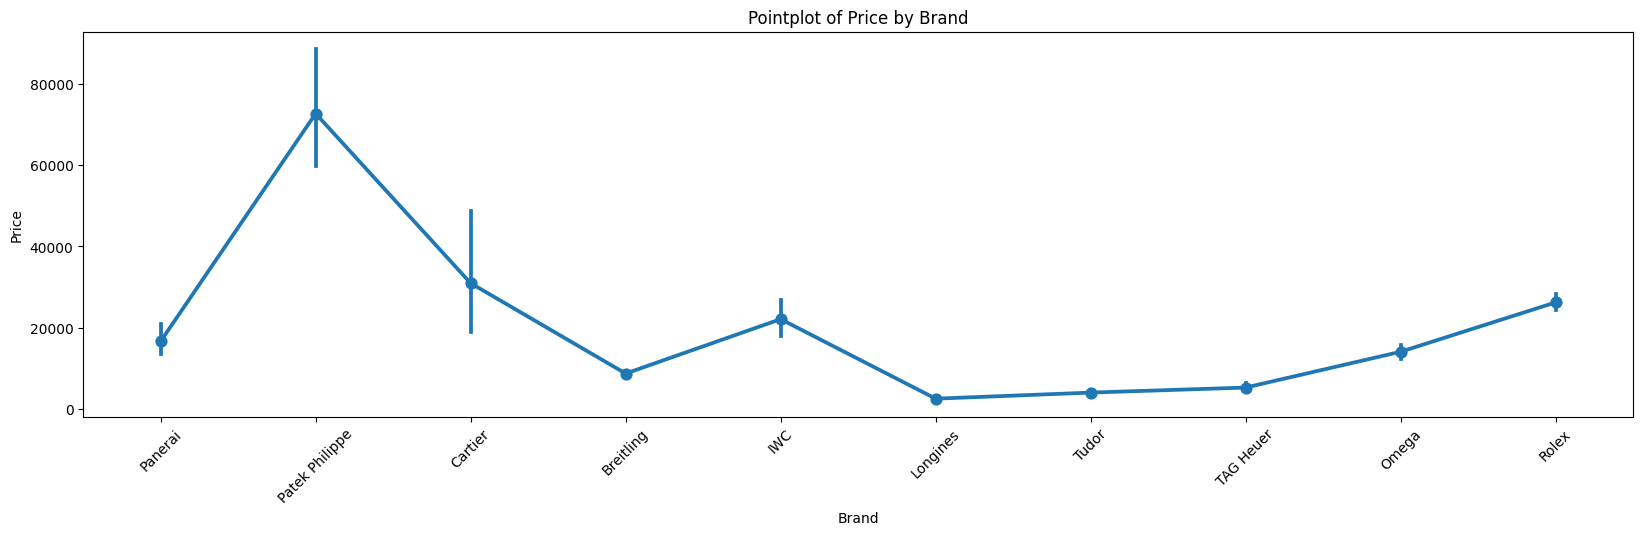

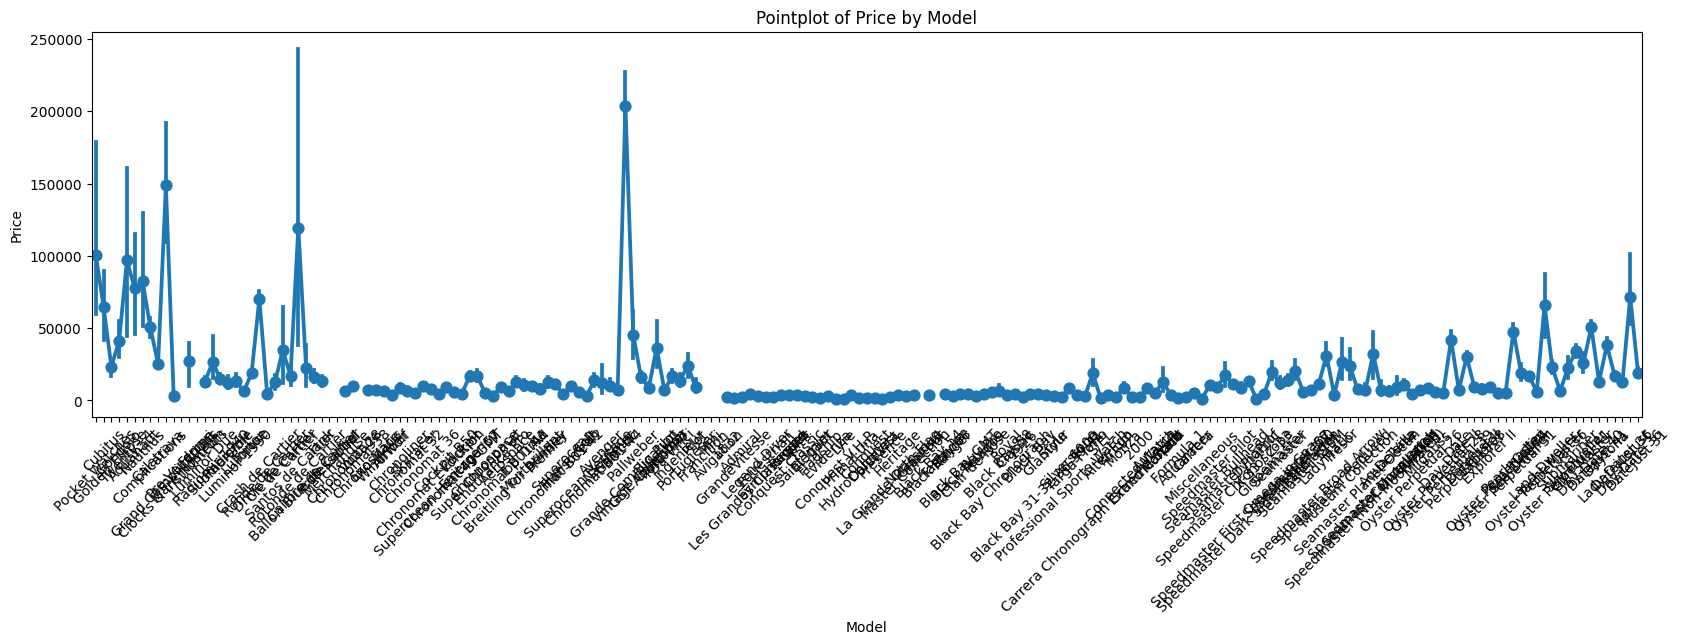

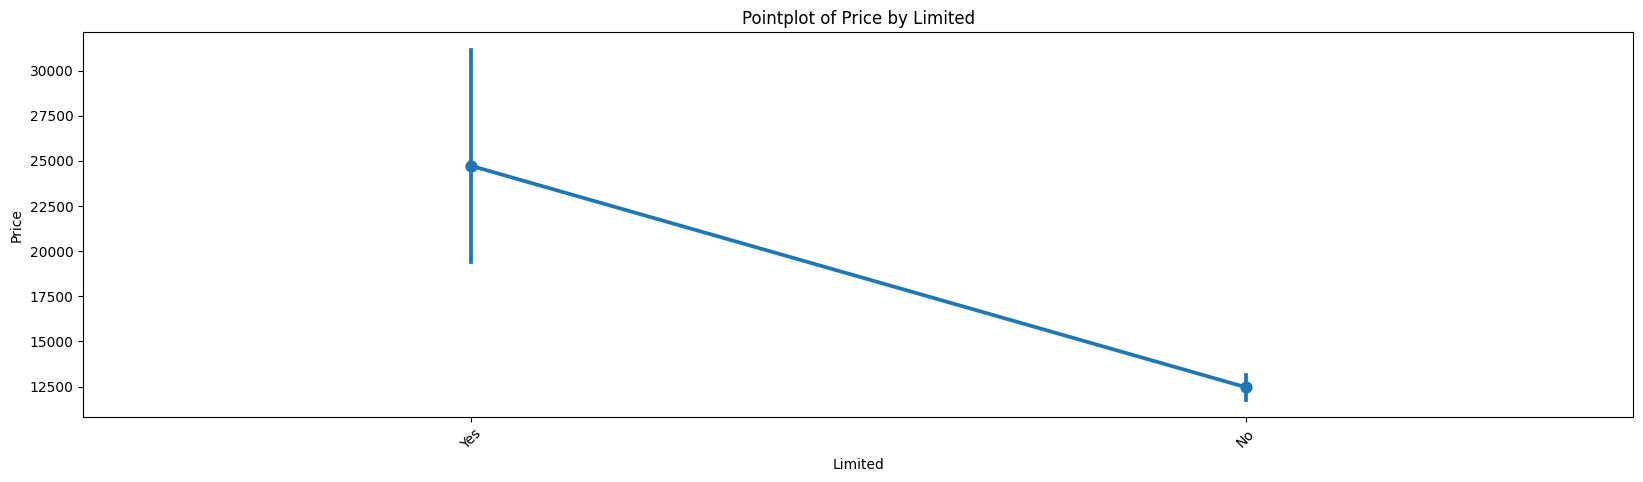

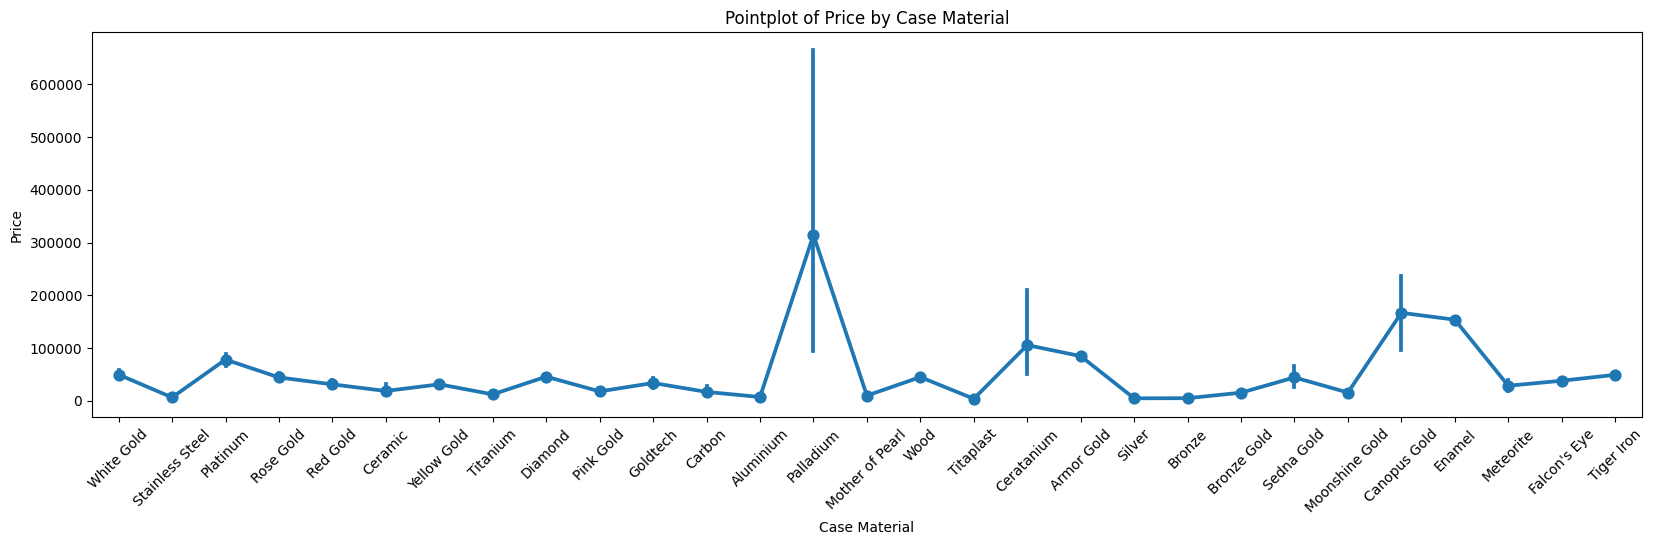

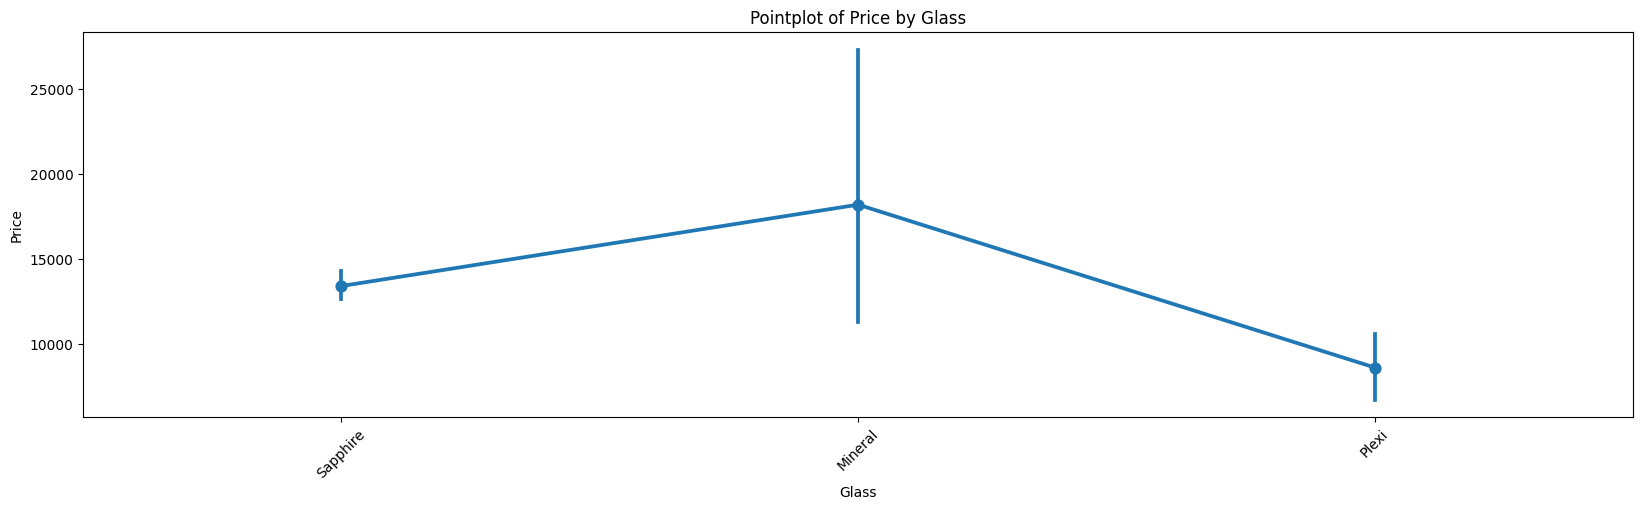

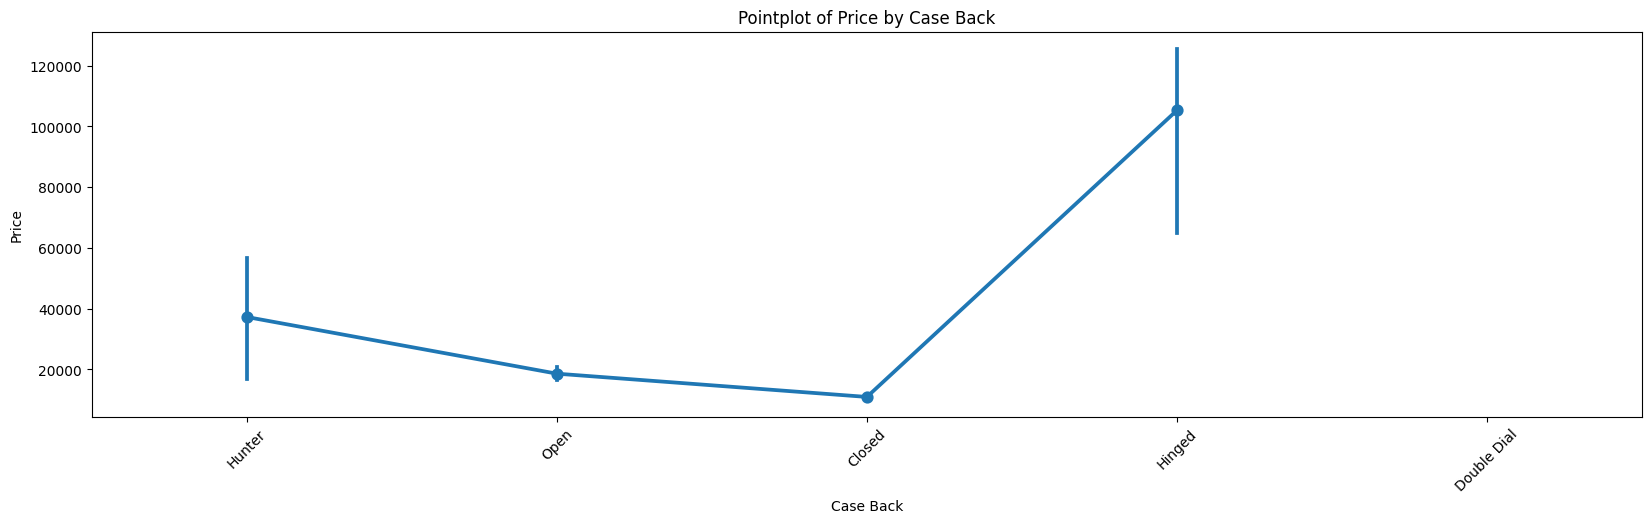

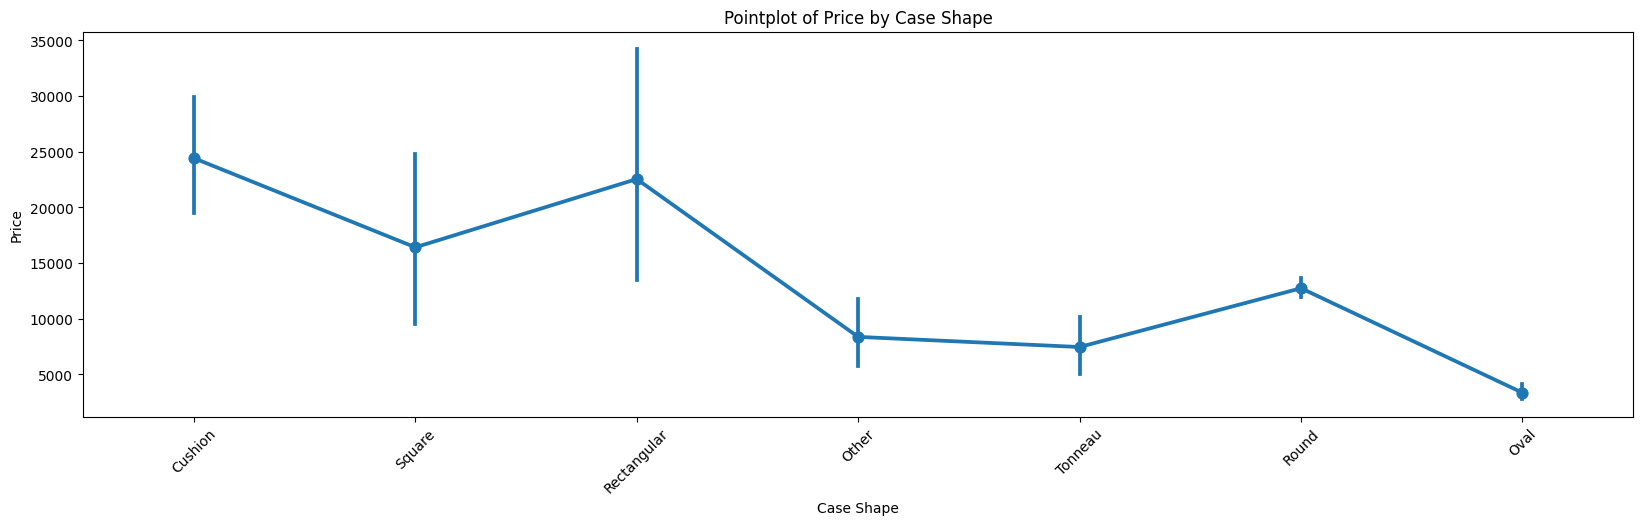

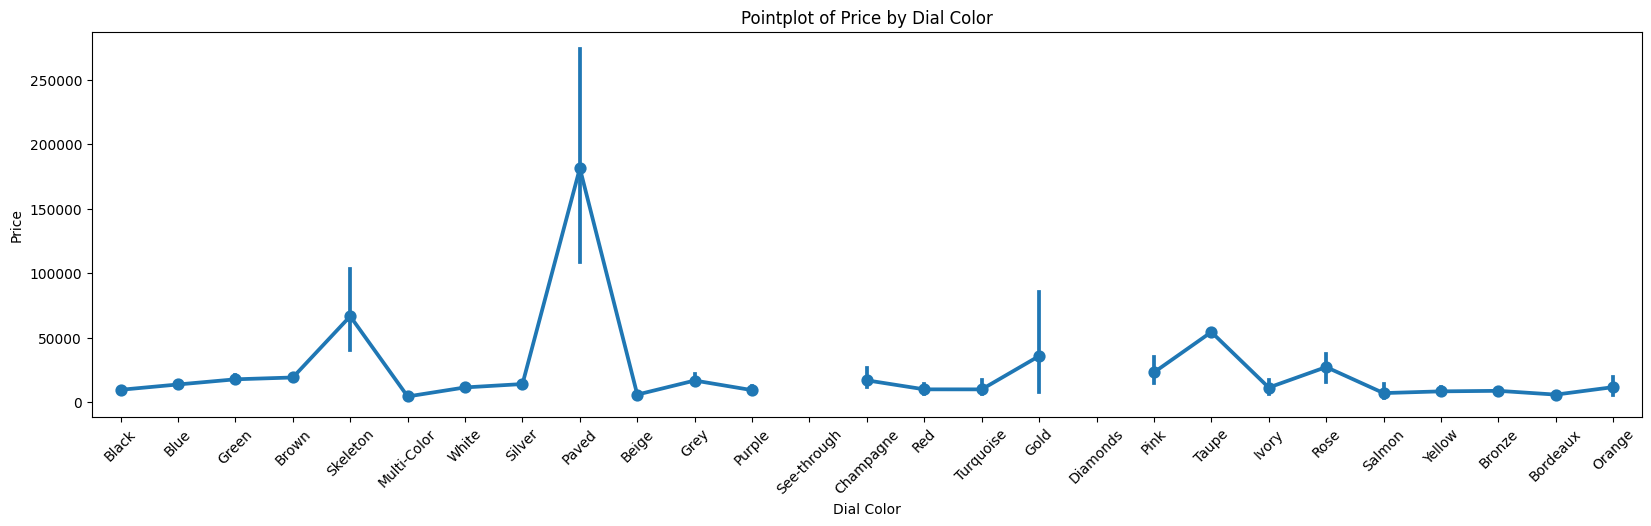

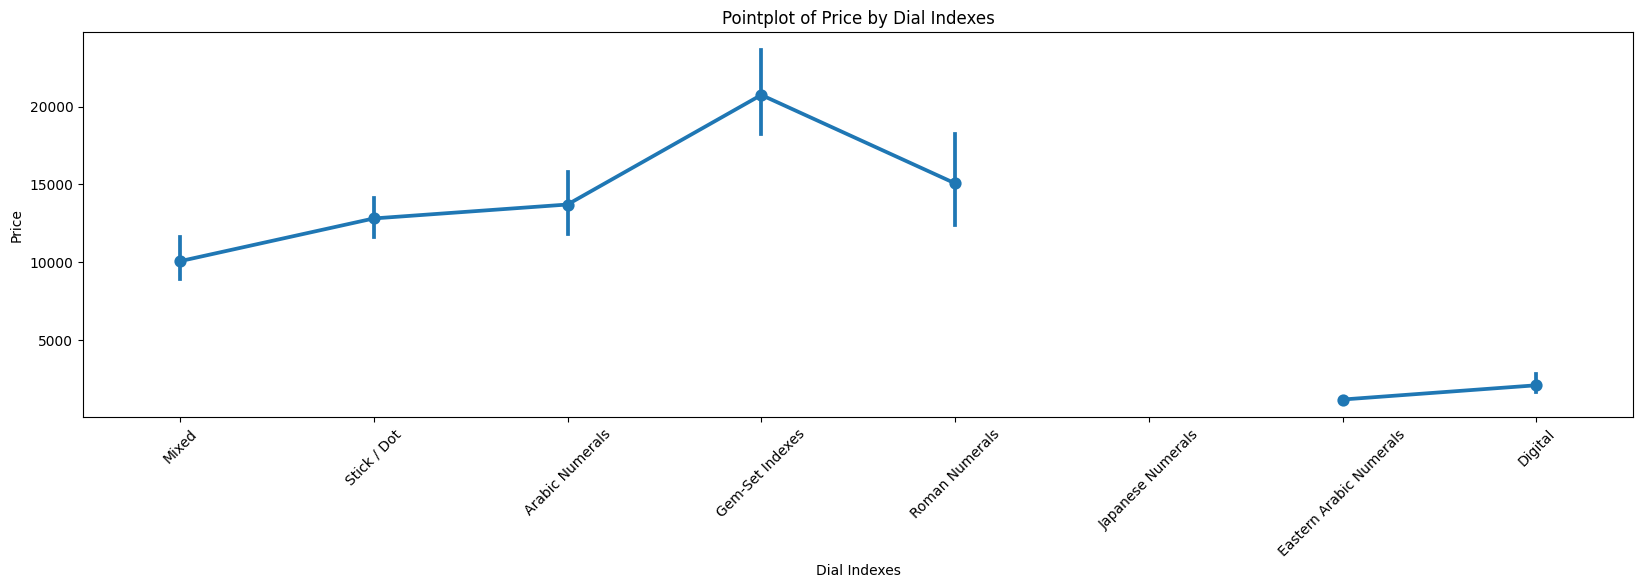

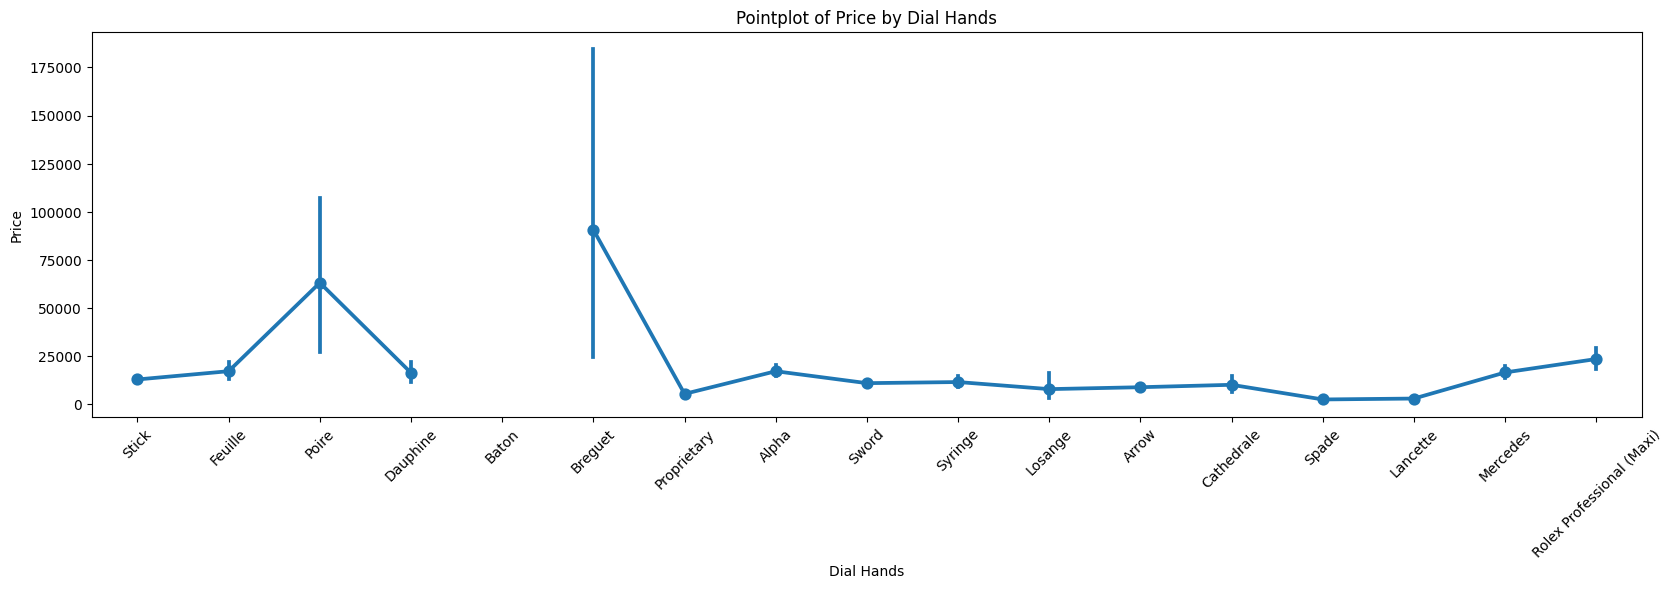

In [12]:
for col in cat_cols:
    plt.figure(figsize=(20, 5))
    sns.pointplot(x=df[col], y=df['Price'])
    plt.title(f'Pointplot of Price by {col}')
    plt.xticks(rotation=45)
    plt.show()

**1. Biểu đồ "Pointplot of Price by Brand"**
- Biểu đồ này cung cấp cái nhìn tổng quan về sự khác biệt về giá trung bình và sự biến động giá giữa các thương hiệu đồng hồ, giúp dễ dàng so sánh vị trí giá của từng thương hiệu trên thị trường. Nó nhấn mạnh rằng Patek Philippe và IWC là những thương hiệu hàng đầu về giá, trong khi Longines và Breitling thuộc phân khúc giá thấp hơn trong nhóm các thương hiệu được khảo sát.

**2. Biểu đồ "Pointplot of Price by Model"**
- Nhìn chung, biểu đồ cho thấy một thị trường đồng hồ với dải giá cực kỳ rộng. Có một số mẫu đồng hồ rất đắt tiền (có thể là hàng hiếm, phiên bản giới hạn, hoặc của các thương hiệu siêu sang), nhưng phần lớn các mẫu trên thị trường có mức giá phải chăng hơn. Sự phân bố giá không đồng đều, với một "đuôi" dài về phía giá cao.

**3. Biểu đồ "Pointplot of Price by Limited"**
- Biểu đồ cho thấy một xu hướng rất rõ ràng: đồng hồ phiên bản giới hạn có giá trung bình cao hơn gấp đôi so với đồng hồ không giới hạn, và đồng thời cũng có sự biến động giá lớn hơn nhiều. Điều này khẳng định rằng tính độc quyền và khan hiếm là những yếu tố then chốt trong việc định giá đồng hồ trên thị trường.

**4. Biểu đồ "Pointplot of Price by Case Material"**
- Biểu đồ cho thấy vật liệu vỏ là một yếu tố cực kỳ quan trọng trong việc định giá đồng hồ. Các vật liệu như Carbon, Enamel và Platinum định vị đồng hồ ở phân khúc giá siêu cao cấp, trong khi Stainless Steel là lựa chọn phổ biến và tiết kiệm hơn. Sự chênh lệch giá và mức độ biến động giá giữa các loại vật liệu phản ánh rõ ràng sự khác biệt về chi phí nguyên liệu, công nghệ chế tác, và định vị thương hiệu.

**5. Biểu đồ "Pointplot of Price by Glass"**
- Biểu đồ cho thấy rằng loại kính có ảnh hưởng đến giá đồng hồ, nhưng mối quan hệ không hoàn toàn đơn giản. Mặc dù kính Sapphire thường được coi là cao cấp, nhưng giá trung bình lại bị ảnh hưởng mạnh bởi sự biến động cực lớn trong phân khúc đồng hồ sử dụng kính Mineral, có thể do sự tồn tại của các mẫu vintage hoặc đặc biệt giá trị. Kính Plexi duy trì vị trí là lựa chọn kinh tế nhất.

**6. Biểu đồ "Pointplot of Price by Case Back"**
- Biểu đồ cho thấy loại nắp lưng có mối tương quan đáng kể với giá của đồng hồ. Các loại nắp lưng đặc biệt hoặc có giá trị sưu tầm cao (như Hinged và Hunter) có xu hướng có giá trung bình cao hơn nhiều. Trong khi đó, nắp lưng Closed phổ biến có giá thấp nhất và ổn định nhất. Sự biến động giá lớn nhất được quan sát ở đồng hồ Hunter, cho thấy đây là một phân khúc rất đa dạng về giá trị.

**7. Biểu đồ "Pointplot of Price by Case Shape"**
- Biểu đồ cho thấy hình dạng vỏ có ảnh hưởng rõ rệt đến giá của đồng hồ. Các hình dạng vỏ không truyền thống như Square và Cushion có xu hướng có giá trung bình cao hơn, đặc biệt là Square với sự biến động giá cực kỳ lớn, cho thấy đây là một phân khúc có cả những mẫu rất cao cấp và các mẫu phổ biến hơn. Trong khi đó, các hình dạng phổ biến như Round và các hình dạng ít được ưa chuộng hơn như Tonneau và Oval có giá trung bình thấp hơn và ổn định hơn.

**8. Biểu đồ "Pointplot of Price by Dial Color"**
- Biểu đồ cho thấy màu sắc/kiểu mặt số là một yếu tố quan trọng ảnh hưởng đến giá đồng hồ. Các mặt số đặc biệt như "Paved" (nạm đá quý) và "Skeleton" (lộ máy) có giá trung bình cao nhất do sự phức tạp, giá trị vật liệu và tính độc đáo. Trong khi đó, các màu sắc truyền thống và phổ biến hơn có mức giá thấp hơn và ổn định hơn. Sự biến động giá lớn nhất được tìm thấy ở các loại mặt số cao cấp, cho thấy sự đa dạng về giá trị trong từng phân khúc.

**9. Biểu đồ "Pointplot of Price by Dial Indexes"**
- Biểu đồ cho thấy loại cọc số/chỉ số trên mặt đồng hồ có ảnh hưởng đáng kể đến giá. Các loại cọc số đặc biệt và xa xỉ như "Gem-Set Indexes" rõ ràng định vị đồng hồ ở phân khúc giá rất cao, mặc dù có sự biến động giá lớn. Trong khi đó, các loại cọc số truyền thống như số Ả Rập, La Mã, vạch, chấm có mức giá trung bình ổn định hơn. Các loại cọc số ít phổ biến hoặc ở phân khúc phổ thông hơn như "Eastern Arabic Numerals" và "Digital" có mức giá thấp nhất.

**10. Biểu đồ "Pointplot of Price by Dial Hands"**
- Biểu đồ cho thấy loại kim đồng hồ có ảnh hưởng đáng kể đến giá. Các loại kim mang tính biểu tượng hoặc cổ điển như Breguet và Poire có giá trung bình cao nhất, chủ yếu do chúng thường được sử dụng trên các mẫu đồng hồ cao cấp và có giá trị sưu tầm. Tuy nhiên, sự biến động giá của chúng cũng rất lớn. Các loại kim phổ biến khác có mức giá trung bình thấp hơn và ổn định hơn, phản ánh sự đa dạng và phổ biến của chúng trên thị trường. Các loại kim đặc trưng của một thương hiệu nổi tiếng như Rolex (Mercedes, Rolex Professional) cũng cho thấy mức giá tốt.

##### Overall Conclusion

**1. Price by Brand:**

- Thương hiệu là yếu tố chi phối mạnh mẽ nhất: Patek Philippe, IWC dẫn đầu về giá, cao hơn hẳn các thương hiệu khác.
Phân khúc giá rõ rệt: Có sự phân hóa rõ ràng giữa các thương hiệu cao cấp (giá rất cao, biến động lớn) và phổ thông (giá thấp, ổn định).

**2. Price by Model:**

- Phân tán giá cực rộng: Thị trường đồng hồ có nhiều mẫu giá phải chăng nhưng cũng tồn tại những mẫu siêu cao cấp (giá trên 200.000), tạo ra sự phân hóa giá rất lớn giữa các mẫu.

**3. Price by Limited:**

- "Limited Edition" tăng tiềm năng giá cực cao: Đồng hồ phiên bản giới hạn có giá trung bình cao hơn gấp đôi và quan trọng hơn là có tiềm năng đạt mức giá rất cao, mặc dù không phải tất cả đều đắt.

**4. Price by Case Material:**

- Vật liệu quý hiếm/công nghệ cao định giá: Carbon, Enamel, Platinum, các loại vàng có giá trung bình rất cao.
Thép không gỉ là phổ biến/kinh tế: Vật liệu như Stainless Steel có giá thấp hơn và ổn định hơn.
Biến động giá lớn ở vật liệu cao cấp: Các vật liệu đắt tiền thường đi kèm với dải lỗi rộng, cho thấy sự đa dạng giá ngay trong cùng một loại vật liệu.

**5. Price by Glass:**

- Kính Mineral có giá trung bình cao bất ngờ: Do có sự hiện diện của các mẫu đồng hồ rất đắt tiền, đặc biệt là mẫu vintage.
Sapphire là phổ biến, Plexi là thấp nhất: Kính Sapphire có giá trung bình khá cao và ổn định, trong khi Plexi ở phân khúc giá thấp nhất.

**6. Price by Case Back:**

- Nắp lưng đặc biệt/cổ điển có giá cao: Loại Hinged và Hunter thường liên quan đến đồng hồ giá cao hơn, đặc biệt Hinged rất cao.
Nắp lưng đóng (Closed) phổ biến và giá thấp: Loại này có giá thấp và ổn định.

**7. Price by Case Shape:**

- Hình vuông (Square) nổi bật về giá: Có giá trung bình cao nhất và biên độ giá rất rộng, cho thấy tiềm năng đạt giá trị rất cao.
Các hình dạng khác đa dạng: Hình tròn phổ biến ở nhiều phân khúc, trong khi Tonneau và Oval có giá thấp hơn.

**8. Price by Dial Color:**

- Mặt số đặc biệt/xa xỉ có giá cao: Skeleton (lộ máy) và Paved (nạm đá) có giá trung bình cực kỳ cao và biên độ giá lớn.
Các màu phổ biến giá thấp hơn: Đen, xanh, bạc, trắng... có giá thấp hơn nhưng vẫn có thể có những sản phẩm đắt tiền.

**9. Price by Dial Indexes:**

- Chỉ số nạm đá quý (Gem-Set Indexes) đắt nhất: Dẫn đầu về giá trung bình và có biên độ giá rất lớn.
Các kiểu truyền thống (số La Mã, Ả Rập, vạch) ổn định: Có giá trung bình tương đối và biến động thấp hơn.

**10. Price by Dial Hands:**

- Kim Breguet và Poire có giá cao nhất: Thường liên quan đến đồng hồ cao cấp và có tiềm năng giá rất lớn, đi kèm với biên độ giá rộng.
- Các loại kim khác phổ biến hơn: Có giá trung bình thấp hơn và ổn định hơn.

**Tóm lại:** 

Giá đồng hồ là một hàm của nhiều biến số. Thương hiệu, việc là phiên bản giới hạn, và vật liệu vỏ (đặc biệt là các loại quý hiếm/công nghệ cao) là những yếu tố có tác động mạnh mẽ nhất đến mức giá trung bình và tiềm năng đạt các giá trị cực kỳ cao. Các yếu tố khác như kiểu mặt số, chỉ số, kim đồng hồ, hình dạng vỏ, và loại nắp lưng cũng đóng góp vào giá trị, đặc biệt khi chúng thể hiện sự phức tạp, độc đáo, hoặc tính xa xỉ trong chế tác. Sự biến động giá lớn trong các phân khúc cao cấp cho thấy giá trị cuối cùng còn phụ thuộc vào các yếu tố chi tiết và đặc điểm riêng biệt của từng sản phẩm.